# **Problem Statement**

## Business Context

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62 bn by 2023 with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc, it is now preferable to traditional education.

In the present scenario due to the Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, like

* The customer interacts with the marketing front on social media or other online platforms.
* The customer browses the website/app and downloads the brochure
* The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

## Objective

ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:
* Analyze and build an ML model to help identify which leads are more likely to convert to paid customers,
* Find the factors driving the lead conversion process
* Create a profile of the leads which are likely to convert

## Data Description

The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.

* **ID**: ID of the lead.
* **age**: Age of the lead.
* **current_occupation**: Current occupation of the lead. Values include 'Professional','Unemployed',and 'Student'.
* **first_interaction**: How did the lead first interacted with ExtraaLearn. Values include 'Website', 'Mobile App'.
* **profile_completed**: What percentage of profile has been filled by the lead on the website/mobile app. Values include Low - (0-50%), Medium - (50-75%), High (75-100%).
* **website_visits**: How many times has a lead visited the website.
* **time_spent_on_website**: Total time spent on the website in seconds.
* **page_views_per_visit**: Average number of pages on the website viewed during the visits.
* **last_activity**: Last interaction between the lead and ExtraaLearn.
    * Email Activity: Seeking for details about program through email, Representative shared information with lead like brochure of program , etc.
    * Phone Activity: Had a Phone Conversation with representative, Had conversation over SMS with representative, etc.
    * Website Activity: Interacted on live chat with representative, Updated profile on website, etc.

* **print_media_type1**: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Newspaper.
* **print_media_type2**: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Magazine.
* **digital_media**: Flag indicating whether the lead had seen the ad of ExtraaLearn on the digital platforms.
* **educational_channels**: Flag indicating whether the lead had heard about ExtraaLearn in the education channels like online forums, discussion threads, educational websites, etc.
* **referral**: Flag indicating whether the lead had heard about ExtraaLearn through reference.
* **status**: Flag indicating whether the lead was converted to a paid customer or not.


# **Installing and Importing the Necessary libraries**

In [ ]:
#Installing the libraries with the specified versions
!pip install -q \
    numpy==2.1.3 \
    pandas==2.2.3 \
    scikit-learn==1.6.1 \
    joblib==1.6.0 \
    matplotlib \
    seaborn \
    xgboost \
    requests \
    huggingface_hub

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# Additional metrics and cross-validation utilities needed for model evaluation
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score


# **Loading the dataset**

In [ ]:
# Loading the dataset
from pathlib import Path
import pandas as pd

DATA_PATH = Path("/content/ExtraaLearn.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "ExtraaLearn.csv was not found at /content/ExtraaLearn.csv. "
        "Upload the CSV to the Colab runtime before running this cell."
    )

df = pd.read_csv(DATA_PATH)

# Keep a copy of the raw data for reference; all further work uses `df`
data = df.copy()

print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded successfully.
Shape: 4612 rows, 15 columns


## **Overview of the dataset**

In [ ]:
# First 5 rows of the dataset
df.head()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


In [ ]:
# Last 5 rows of the dataset
df.tail()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
4607,EXT4608,35,Unemployed,Mobile App,Medium,15,360,2.170,Phone Activity,No,No,No,Yes,No,0
4608,EXT4609,55,Professional,Mobile App,Medium,8,2327,5.393,Email Activity,No,No,No,No,No,0
4609,EXT4610,58,Professional,Website,High,2,212,2.692,Email Activity,No,No,No,No,No,1
4610,EXT4611,57,Professional,Mobile App,Medium,1,154,3.879,Website Activity,Yes,No,No,No,No,0
4611,EXT4612,55,Professional,Website,Medium,4,2290,2.075,Phone Activity,No,No,No,No,No,0


In [ ]:
# Shape of the dataset
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 4612 rows and 15 columns.


### Data Types and Structure

In [ ]:
# Data types of each column and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64  
dtypes: f

In [ ]:
# Explicit dtype listing
df.dtypes

,0
ID,object
age,int64
current_occupation,object
first_interaction,object
profile_completed,object
website_visits,int64
time_spent_on_website,int64
page_views_per_visit,float64
last_activity,object
print_media_type1,object


### Unique Values in Categorical Columns

In [ ]:
# Identify categorical (object/string) columns
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("Categorical columns:", categorical_cols)
print()

# Number of unique values per categorical column
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique value(s)")

Categorical columns: ['ID', 'current_occupation', 'first_interaction', 'profile_completed', 'last_activity', 'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral']

ID: 4612 unique value(s)
current_occupation: 3 unique value(s)
first_interaction: 2 unique value(s)
profile_completed: 3 unique value(s)
last_activity: 3 unique value(s)
print_media_type1: 2 unique value(s)
print_media_type2: 2 unique value(s)
digital_media: 2 unique value(s)
educational_channels: 2 unique value(s)
referral: 2 unique value(s)


In [ ]:
# Actual unique category labels for each categorical column
# (ID is an identifier, so we only display its unique count above, not its labels)
for col in categorical_cols:
    if col == "ID":
        continue
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- current_occupation ---
current_occupation
Professional    2616
Unemployed      1441
Student          555
Name: count, dtype: int64

--- first_interaction ---
first_interaction
Website       2542
Mobile App    2070
Name: count, dtype: int64

--- profile_completed ---
profile_completed
High      2264
Medium    2241
Low        107
Name: count, dtype: int64

--- last_activity ---
last_activity
Email Activity      2278
Phone Activity      1234
Website Activity    1100
Name: count, dtype: int64

--- print_media_type1 ---
print_media_type1
No     4115
Yes     497
Name: count, dtype: int64

--- print_media_type2 ---
print_media_type2
No     4379
Yes     233
Name: count, dtype: int64

--- digital_media ---
digital_media
No     4085
Yes     527
Name: count, dtype: int64

--- educational_channels ---
educational_channels
No     3907
Yes     705
Name: count, dtype: int64

--- referral ---
referral
No     4519
Yes      93
Name: count, dtype: int64



### Missing Values

In [ ]:
# Check for missing values in every column
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})
missing_summary

,Missing Count,Missing %
ID,0,0.0
age,0,0.0
current_occupation,0,0.0
first_interaction,0,0.0
profile_completed,0,0.0
website_visits,0,0.0
time_spent_on_website,0,0.0
page_views_per_visit,0,0.0
last_activity,0,0.0
print_media_type1,0,0.0


### Duplicate Records

In [ ]:
# Check for fully duplicated rows
n_duplicate_rows = df.duplicated().sum()
print(f"Number of fully duplicated rows: {n_duplicate_rows}")

# Check for duplicate lead IDs (ID should be unique per lead)
n_duplicate_ids = df["ID"].duplicated().sum()
print(f"Number of duplicate ID values: {n_duplicate_ids}")
print(f"Number of unique ID values: {df['ID'].nunique()} (out of {df.shape[0]} total rows)")

Number of fully duplicated rows: 0
Number of duplicate ID values: 0
Number of unique ID values: 4612 (out of 4612 total rows)


### Statistical Summary

In [ ]:
# Statistical summary of numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4612.0,46.201214,13.161454,18.0,36.00000,51.000,57.00000,63.000
website_visits,4612.0,3.566782,2.829134,0.0,2.00000,3.000,5.00000,30.000
time_spent_on_website,4612.0,724.011275,743.828683,0.0,148.75000,376.000,1336.75000,2537.000
page_views_per_visit,4612.0,3.026126,1.968125,0.0,2.07775,2.792,3.75625,18.434
status,4612.0,0.298569,0.457680,0.0,0.00000,0.000,1.00000,1.000


In [ ]:
# Statistical summary of categorical variables
df.describe(include="object").T

,count,unique,top,freq
ID,4612,4612,EXT4612,1
current_occupation,4612,3,Professional,2616
first_interaction,4612,2,Website,2542
profile_completed,4612,3,High,2264
last_activity,4612,3,Email Activity,2278
print_media_type1,4612,2,No,4115
print_media_type2,4612,2,No,4379
digital_media,4612,2,No,4085
educational_channels,4612,2,No,3907
referral,4612,2,No,4519


### Target Variable (`status`) Distribution

In [ ]:
# status is already a binary numeric target: 0 = Not Converted, 1 = Converted
print("Count of each class:")
print(df["status"].value_counts())
print()
print("Proportion of each class:")
print(df["status"].value_counts(normalize=True).round(4))
print()

conversion_rate = df["status"].mean()
print(f"Actual conversion rate: {conversion_rate:.4f} ({conversion_rate*100:.2f}%)")

Count of each class:
status
0    3235
1    1377
Name: count, dtype: int64

Proportion of each class:
status
0    0.7014
1    0.2986
Name: proportion, dtype: float64

Actual conversion rate: 0.2986 (29.86%)


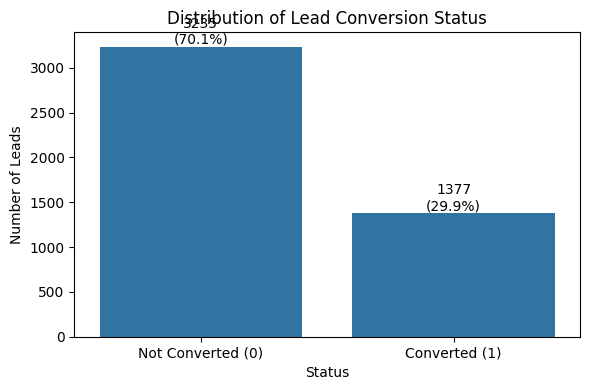

In [ ]:
# Visualizing the target distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="status")
ax.set_xticklabels(["Not Converted (0)", "Converted (1)"])
plt.title("Distribution of Lead Conversion Status")
plt.xlabel("Status")
plt.ylabel("Number of Leads")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}\n({100*p.get_height()/len(df):.1f}%)",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

## Initial Data Understanding — Key Observations

- The dataset contains **4,612 leads** and **15 columns** (13 potential predictors, 1 identifier `ID`, and the target `status`).
- There are **no missing values** in any of the 15 columns — no imputation is required at this stage.
- There are **no fully duplicated rows** and **no duplicate `ID` values** — every row represents a distinct lead, and `ID` is confirmed to be a unique identifier (not useful as a predictive feature; it will be dropped before modeling).
- The target `status` is already a **binary numeric variable** (0 = Not Converted, 1 = Converted), so no re-mapping is needed.
- The dataset is **moderately imbalanced**: about **70.1% of leads did not convert** (status = 0, 3,235 leads) and about **29.9% converted** (status = 1, 1,377 leads). This ~70/30 split means accuracy alone would be a misleading metric later, since a model predicting "not converted" for every lead would already score ~70% accuracy.
- Numeric features (`age`, `website_visits`, `time_spent_on_website`, `page_views_per_visit`) span plausible ranges with no negative values, which is a good early sign of data quality (e.g., `age` ranges 18–63, `website_visits` ranges 0–30).
- Categorical fields (`current_occupation`, `first_interaction`, `profile_completed`, `last_activity`, and the five Yes/No exposure flags: `print_media_type1`, `print_media_type2`, `digital_media`, `educational_channels`, `referral`) all have a small, clean set of category labels with no stray or inconsistent values observed.
- Category level counts are notably imbalanced within several categorical features (e.g., `referral` = "Yes" for only 93 of 4,612 leads; `profile_completed` = "Low" for only 107 leads), which will be worth keeping in mind during bivariate analysis and encoding.

This initial understanding confirms the dataset is clean and well-structured going into EDA — the focus can move directly to univariate and bivariate analysis rather than data cleaning.

# **Exploratory Data Analysis**

**The below functions need to be defined to carry out the EDA.**

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [ ]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0])

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
    )

    plt.tight_layout()
    plt.show()

### Univariate Analysis

#### Numerical Variables

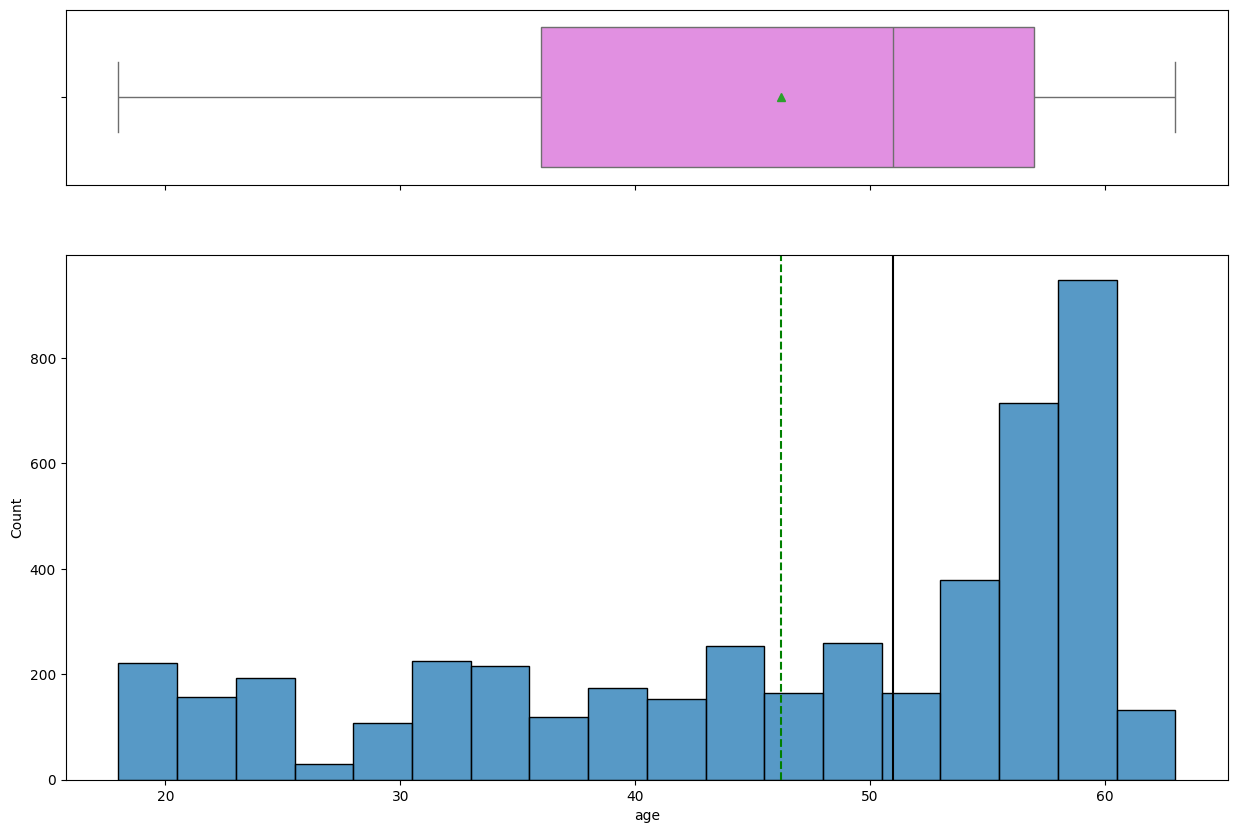

In [ ]:
histogram_boxplot(df, "age")

**Observation — `age`:** The distribution is spread across the working-age range with a visible concentration in the upper end (a large group in the 50s and another cluster of younger leads in their 20s). The median age is above the mean would suggest, so the boxplot should be checked for skew direction; no extreme outliers are flagged by the boxplot.

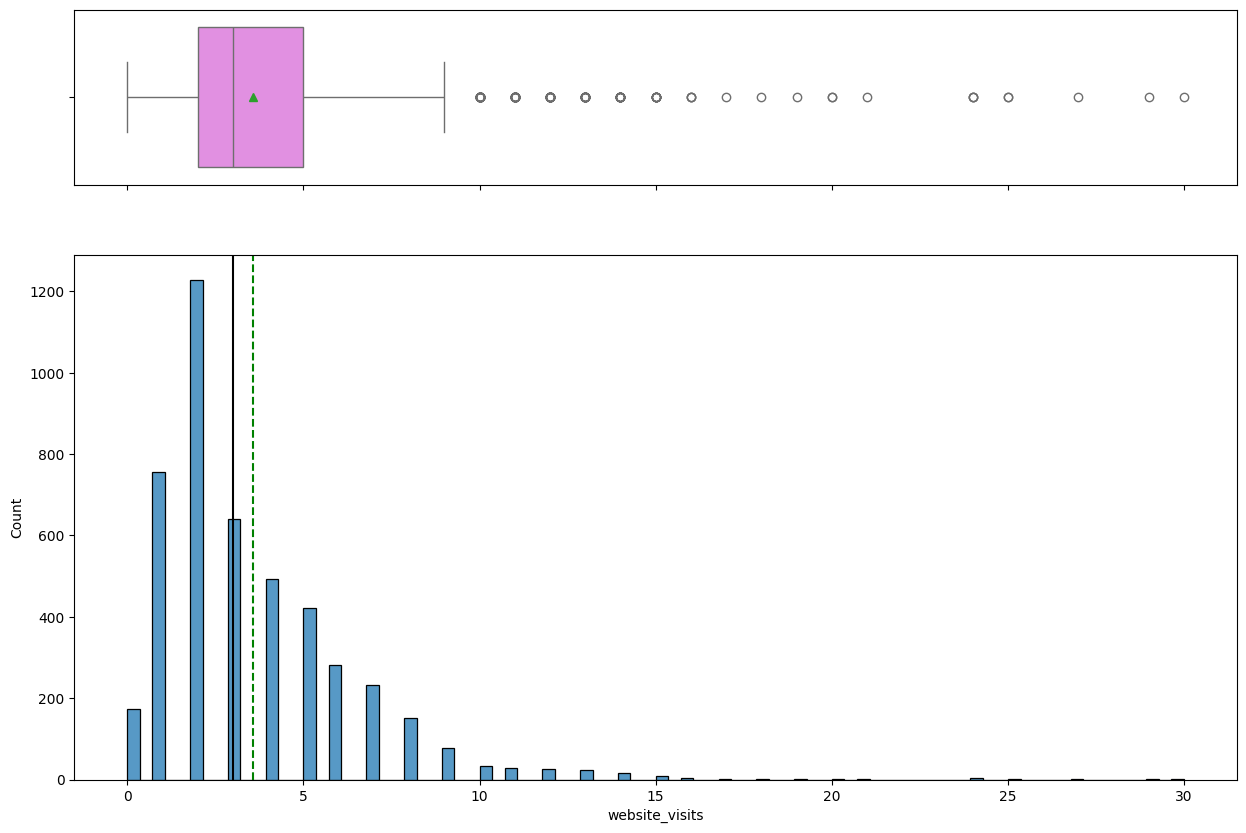

In [ ]:
histogram_boxplot(df, "website_visits")

**Observation — `website_visits`:** The distribution is right-skewed — most leads visit the website only a handful of times (median around 3), while a smaller number of leads visit far more frequently. The boxplot shows a number of points beyond the upper whisker, consistent with the ~3.3% IQR-based outlier rate identified earlier; these will be evaluated (not removed) in the dedicated outlier-treatment step.

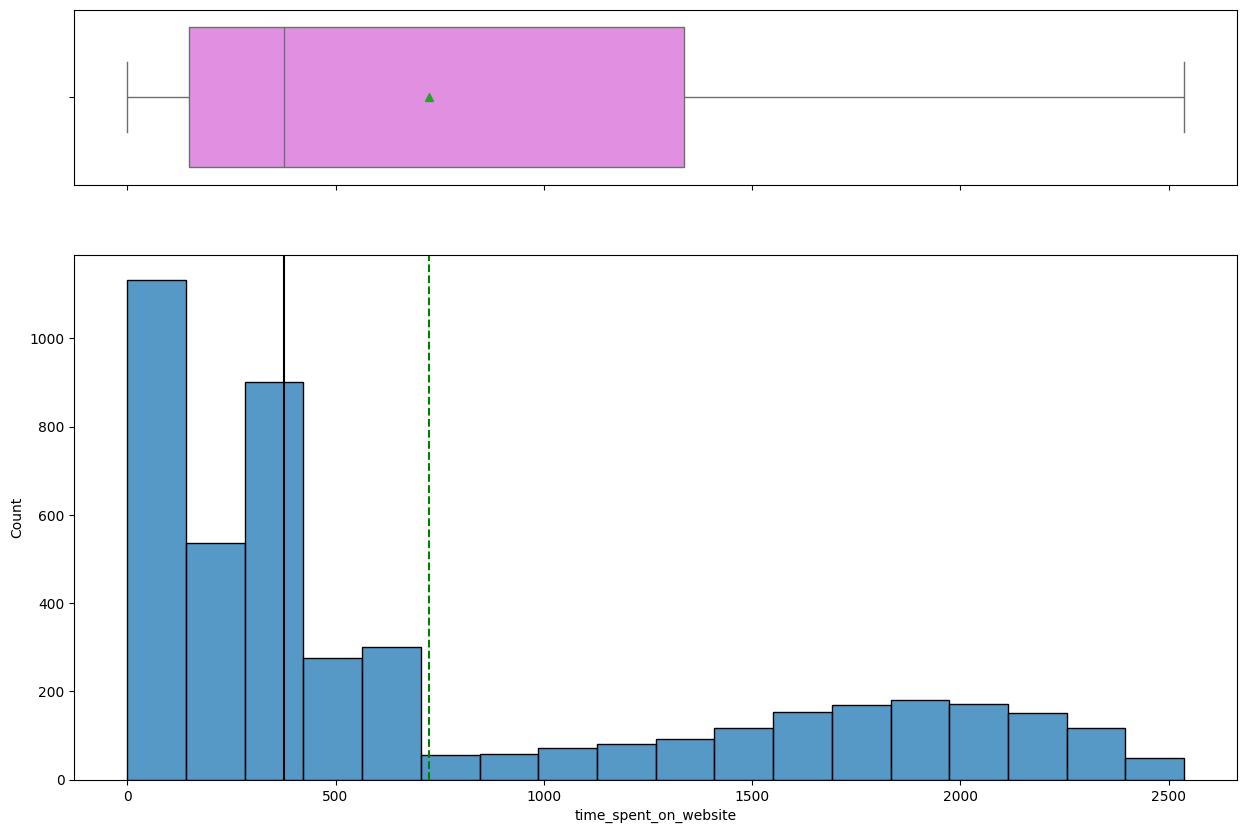

In [ ]:
histogram_boxplot(df, "time_spent_on_website")

**Observation — `time_spent_on_website`:** This variable is also right-skewed, with many leads spending very little time on the site and a smaller group spending a large amount of time (up to the low thousands of seconds). The boxplot shows no points beyond the whiskers, consistent with the earlier IQR check that found 0% outliers for this variable — the spread is wide but not flagged as anomalous.

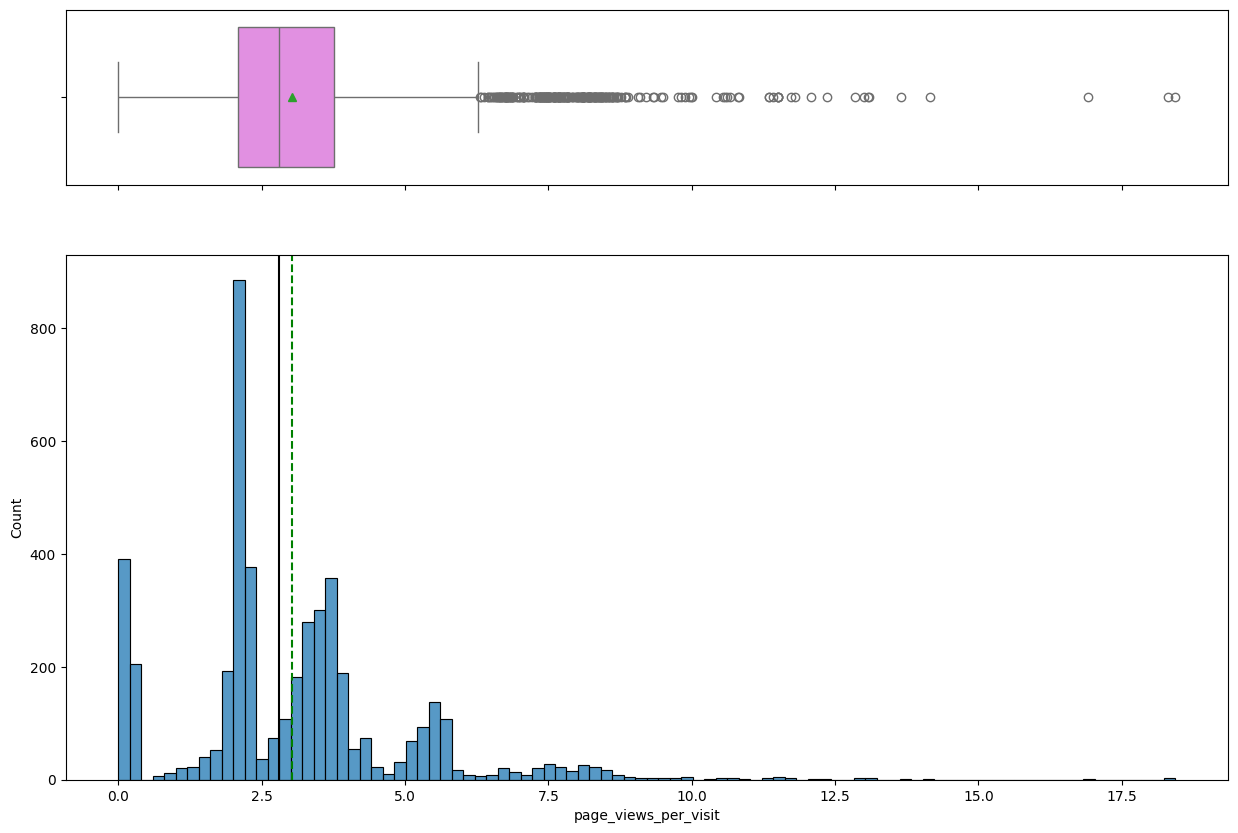

In [ ]:
histogram_boxplot(df, "page_views_per_visit")

**Observation — `page_views_per_visit`:** The bulk of leads view a modest number of pages per visit (median under 3), with a right-skewed tail of highly engaged leads viewing considerably more pages. The boxplot flags a number of high-end points beyond the upper whisker, in line with the ~5.6% IQR-based outlier rate found earlier.

#### Categorical Variables

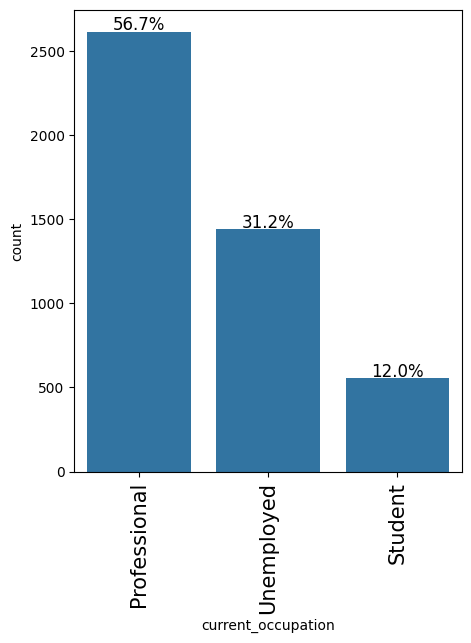

In [ ]:
labeled_barplot(df, "current_occupation", perc=True)

**Observation — `current_occupation`:** The majority of leads are Professionals, followed by Unemployed individuals, with Students making up the smallest group. This reflects ExtraaLearn's core audience of working professionals looking to upskill/reskill.

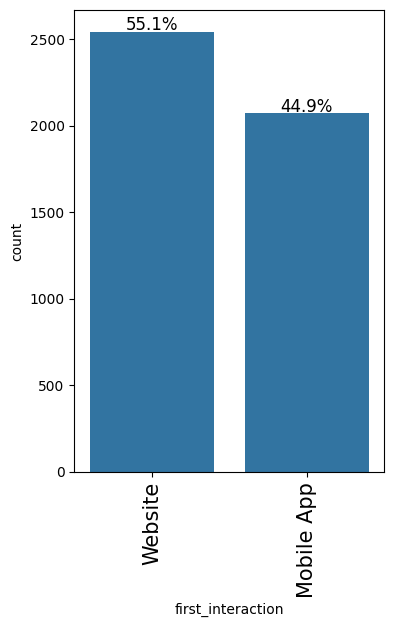

In [ ]:
labeled_barplot(df, "first_interaction", perc=True)

**Observation — `first_interaction`:** More leads first interact with ExtraaLearn through the Website than the Mobile App, though the split is not extreme — both channels are meaningful lead sources.

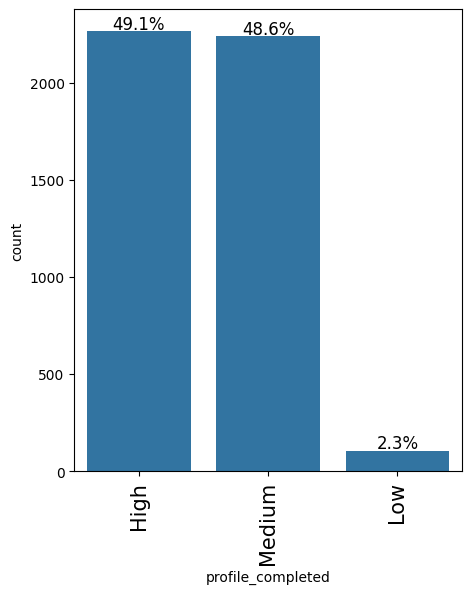

In [ ]:
labeled_barplot(df, "profile_completed", perc=True)

**Observation — `profile_completed`:** Leads are concentrated almost evenly between High and Medium profile completion, while very few leads fall into the Low completion category — most leads who engage at all tend to fill out a reasonable portion of their profile.

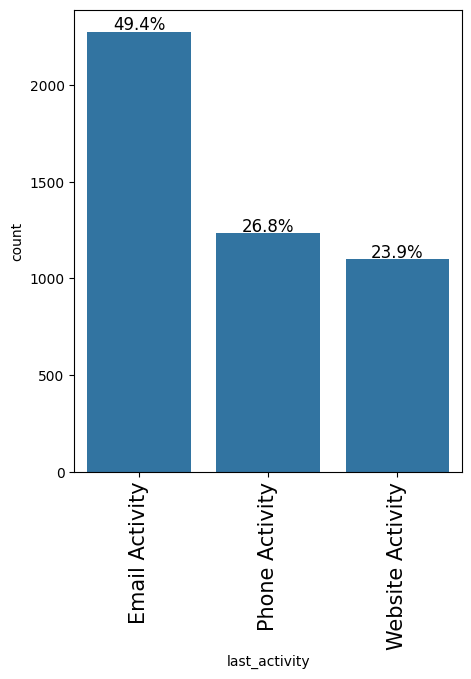

In [ ]:
labeled_barplot(df, "last_activity", perc=True)

**Observation — `last_activity`:** Email Activity is the most common last recorded activity, followed by Phone Activity and then Website Activity — suggesting email-based engagement (e.g., brochure requests, information seeking) is the most frequent touchpoint before conversion or drop-off.

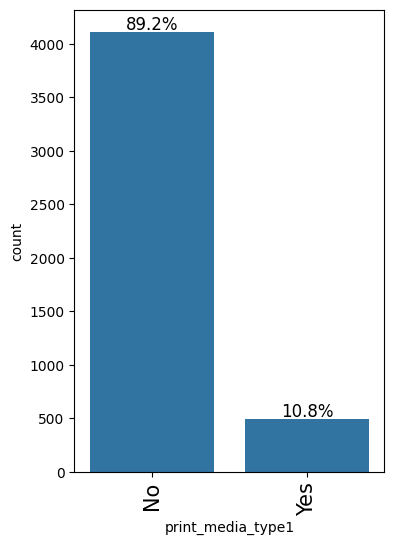

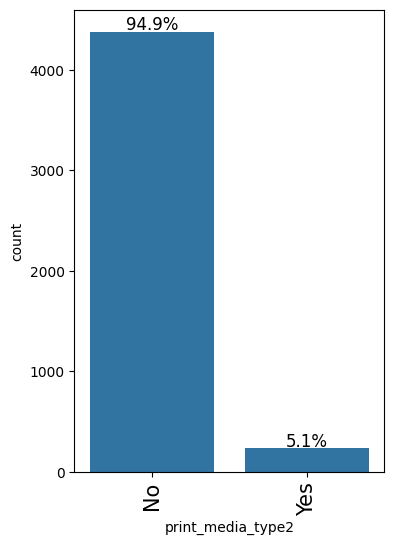

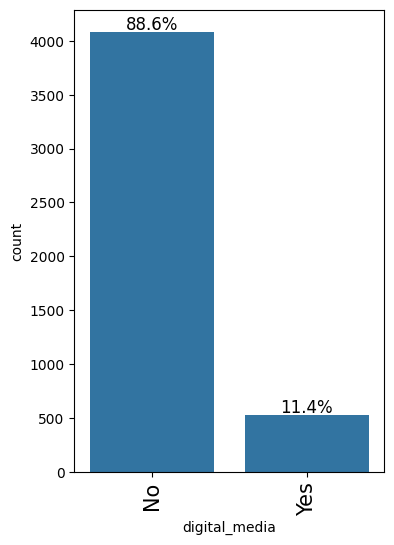

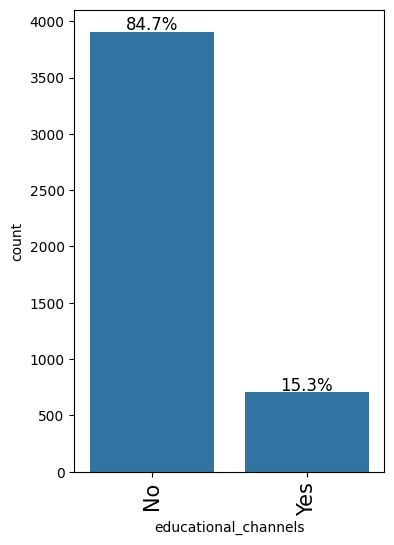

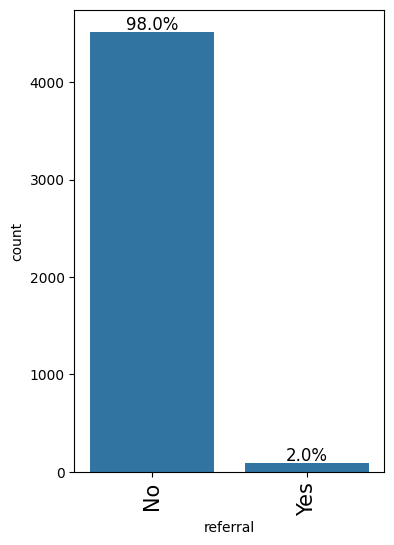

In [ ]:
# Marketing-channel exposure flags (Yes/No)
marketing_flags = [
    "print_media_type1",
    "print_media_type2",
    "digital_media",
    "educational_channels",
    "referral",
]

for flag in marketing_flags:
    labeled_barplot(df, flag, perc=True)

**Observation — Marketing-channel flags (`print_media_type1`, `print_media_type2`, `digital_media`, `educational_channels`, `referral`):** Exposure to every individual marketing channel is a minority case — the large majority of leads report "No" for each flag. `referral` has the smallest "Yes" share of all the channels, while `digital_media` and `print_media_type1` have relatively higher (though still minority) "Yes" shares. This heavy class imbalance within each flag is worth keeping in mind when interpreting their relationship with conversion.

**Note on the target variable (`status`):** The distribution of `status` (converted vs. not converted) and the actual conversion rate were already computed and visualized in the *Data Overview* section above (70.14% not converted vs. 29.86% converted). That analysis is not repeated here to avoid duplicate plots.

### Bivariate Analysis

#### Numerical Variables vs. `status`

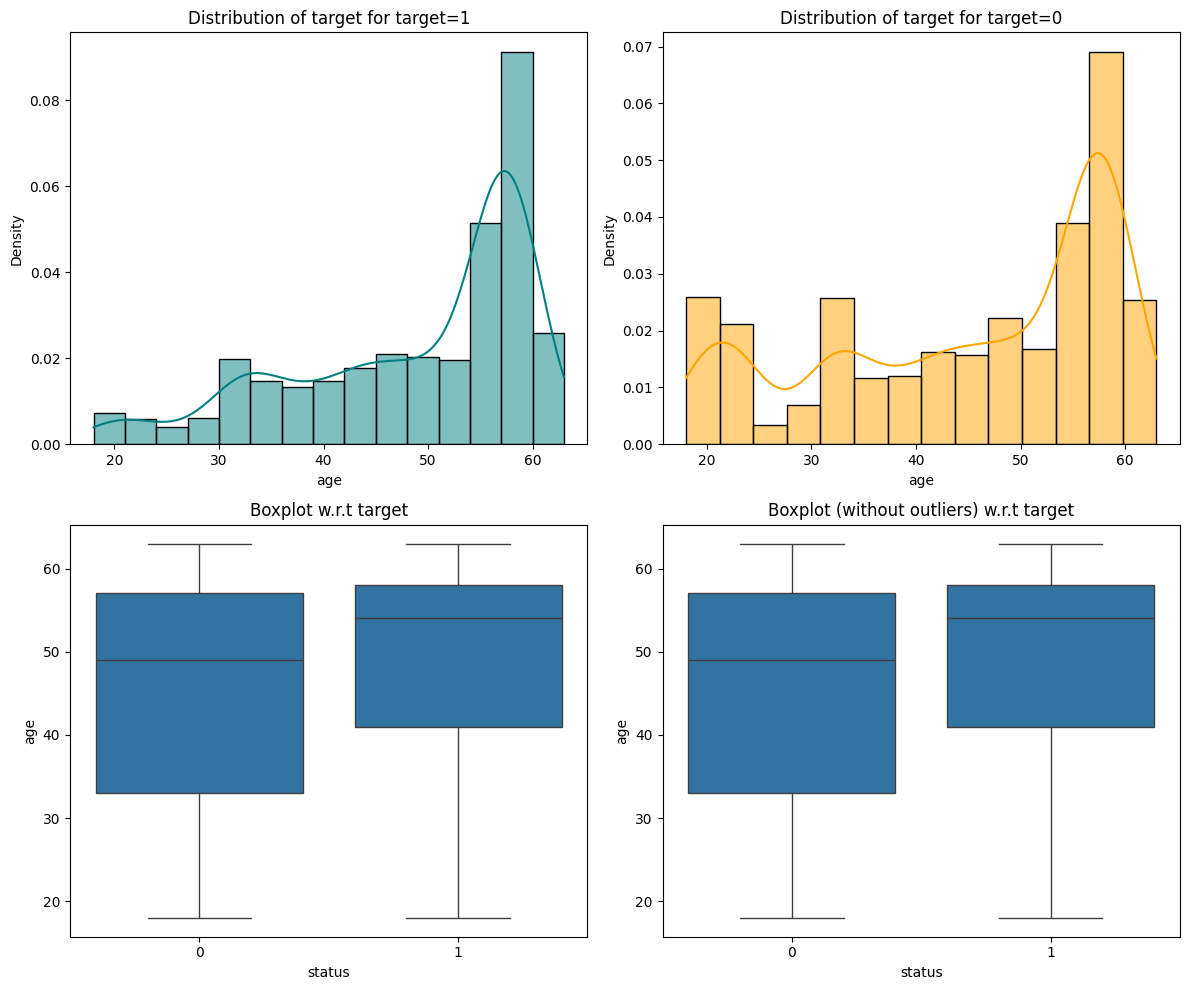

In [ ]:
distribution_plot_wrt_target(df, "age", "status")

In [ ]:
print("Median age by status:")
print(df.groupby("status")["age"].median())
print()
print("Mean age by status:")
print(df.groupby("status")["age"].mean().round(2))

Median age by status:
status
0    49.0
1    54.0
Name: age, dtype: float64

Mean age by status:
status
0    45.15
1    48.66
Name: age, dtype: float64


**Observation — `age` vs. `status`:** Converted leads are noticeably older on average — the median age is 54 for converted leads vs. 49 for non-converted leads, and the mean age is 48.66 vs. 45.15. Older leads appear more likely to convert, which is consistent with ExtraaLearn's target audience of established professionals looking to upskill.

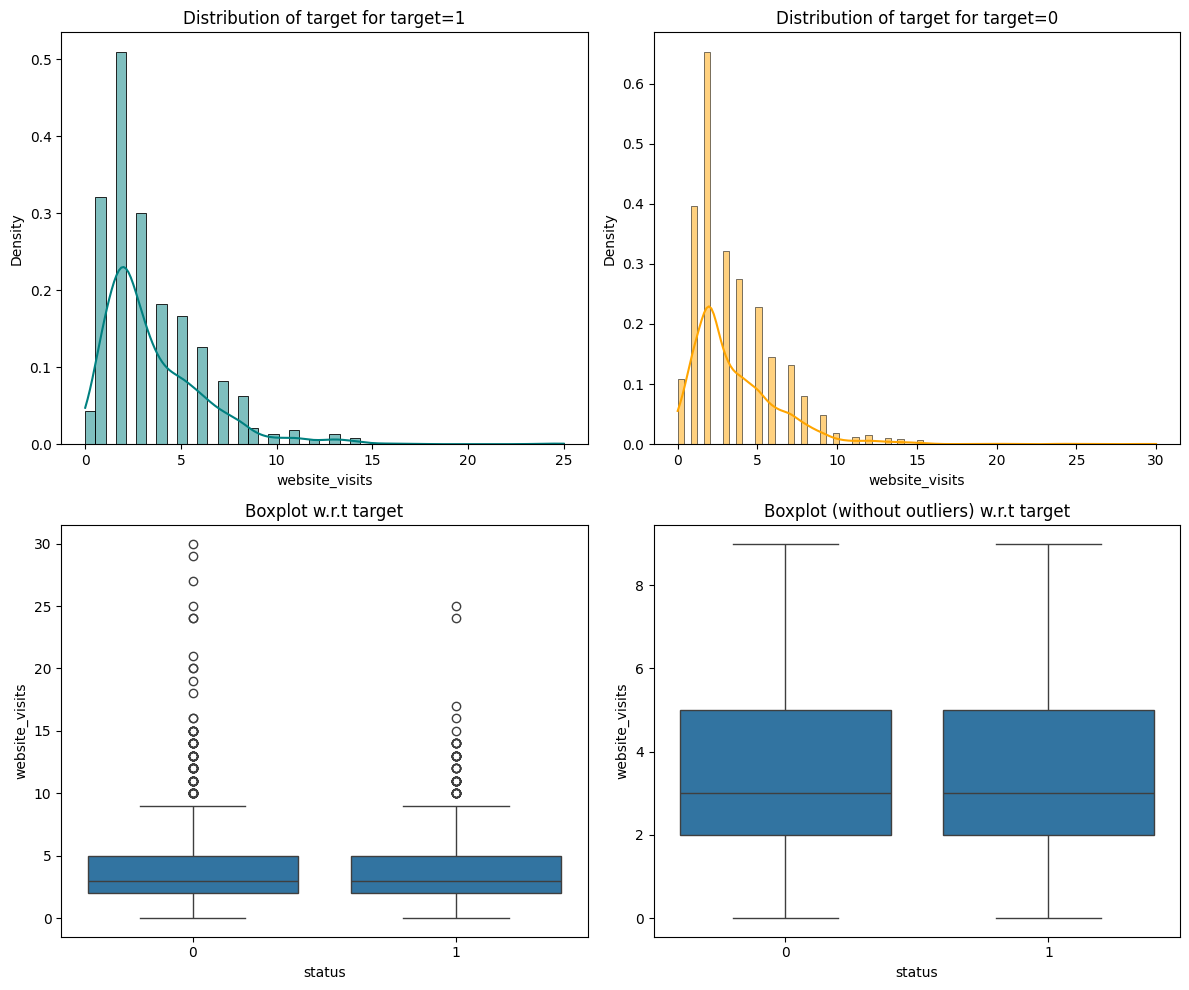

In [ ]:
distribution_plot_wrt_target(df, "website_visits", "status")

In [ ]:
print("Median website_visits by status:")
print(df.groupby("status")["website_visits"].median())
print()
print("Mean website_visits by status:")
print(df.groupby("status")["website_visits"].mean().round(2))

Median website_visits by status:
status
0    3.0
1    3.0
Name: website_visits, dtype: float64

Mean website_visits by status:
status
0    3.58
1    3.54
Name: website_visits, dtype: float64


**Observation — `website_visits` vs. `status`:** The number of website visits shows almost no difference between converted and non-converted leads (median 3 visits for both groups; mean 3.54 for converted vs. 3.58 for non-converted). Simply visiting the site more often does not appear to be associated with a higher conversion likelihood — how leads engage seems to matter more than how often they show up.

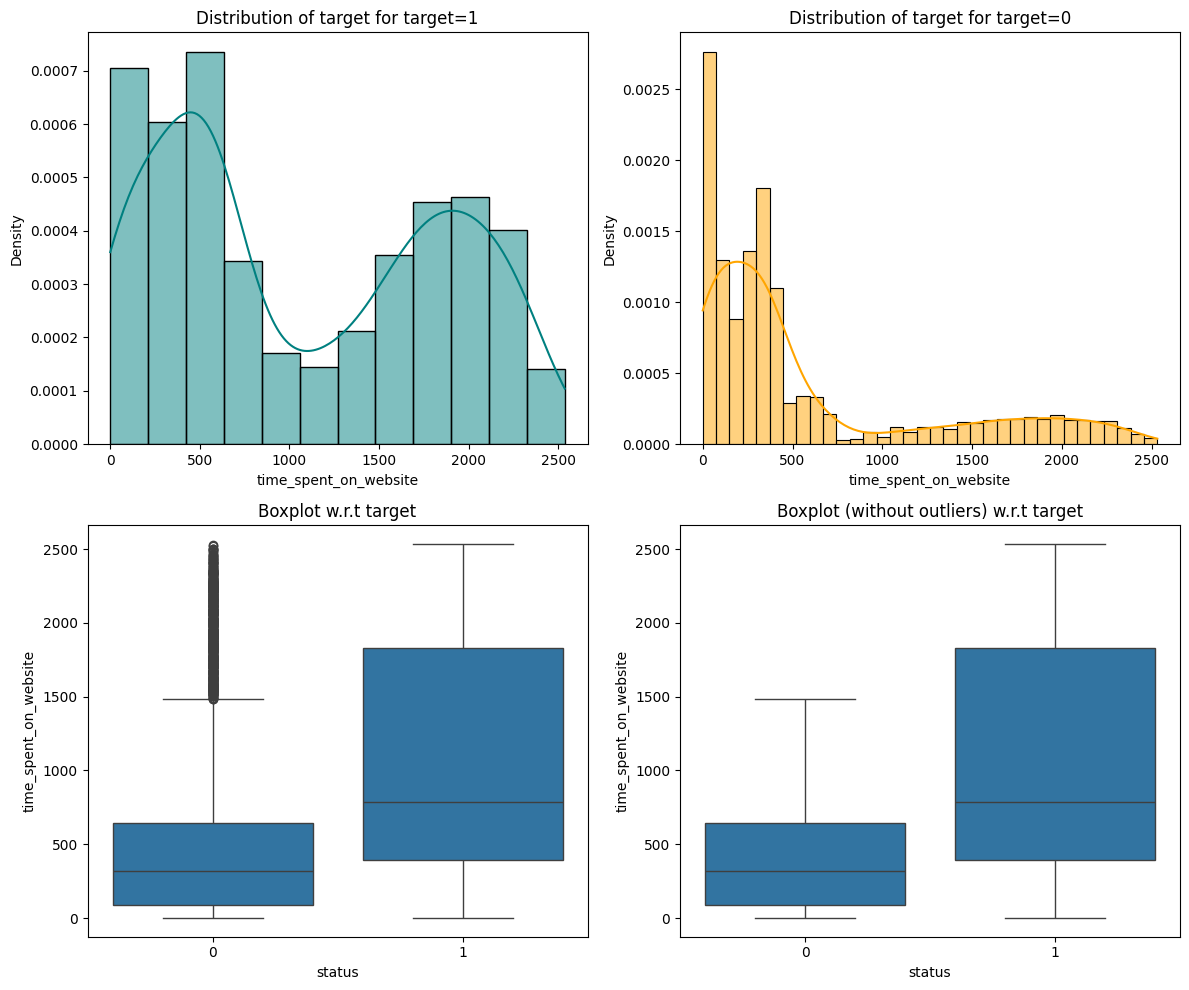

In [ ]:
distribution_plot_wrt_target(df, "time_spent_on_website", "status")

In [ ]:
print("Median time_spent_on_website by status:")
print(df.groupby("status")["time_spent_on_website"].median())
print()
print("Mean time_spent_on_website by status:")
print(df.groupby("status")["time_spent_on_website"].mean().round(2))

Median time_spent_on_website by status:
status
0    317.0
1    789.0
Name: time_spent_on_website, dtype: float64

Mean time_spent_on_website by status:
status
0     577.42
1    1068.40
Name: time_spent_on_website, dtype: float64


**Observation — `time_spent_on_website` vs. `status`:** This shows one of the clearest differences in the dataset. Converted leads spend far more time on the website — median 789 seconds vs. 317 seconds for non-converted leads, and mean 1,068 seconds vs. 577 seconds (nearly double). Time spent on the website appears to be a strong behavioral signal of conversion likelihood.

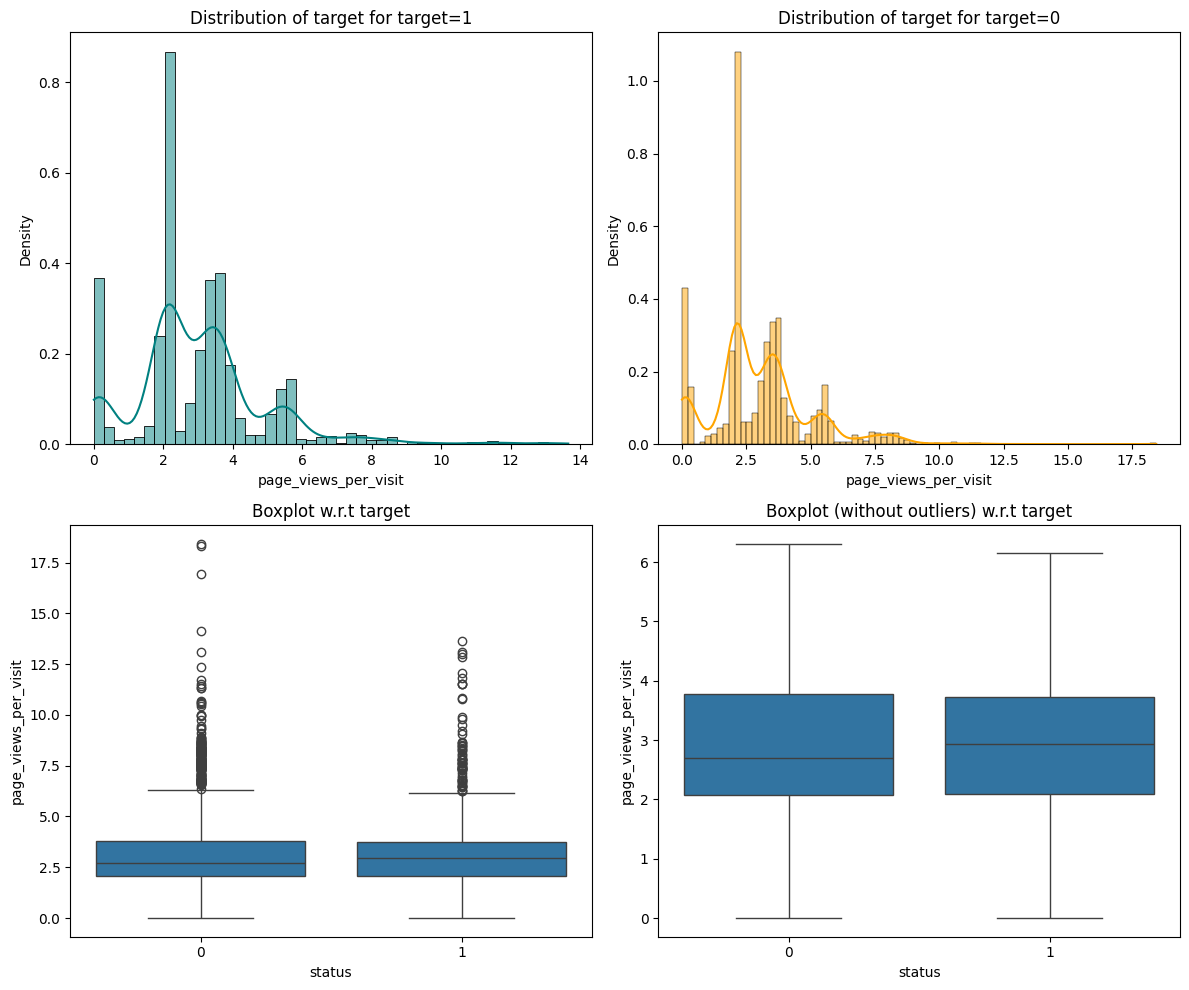

In [ ]:
distribution_plot_wrt_target(df, "page_views_per_visit", "status")

In [ ]:
print("Median page_views_per_visit by status:")
print(df.groupby("status")["page_views_per_visit"].median())
print()
print("Mean page_views_per_visit by status:")
print(df.groupby("status")["page_views_per_visit"].mean().round(2))

Median page_views_per_visit by status:
status
0    2.706
1    2.935
Name: page_views_per_visit, dtype: float64

Mean page_views_per_visit by status:
status
0    3.03
1    3.03
Name: page_views_per_visit, dtype: float64


**Observation — `page_views_per_visit` vs. `status`:** The difference here is small. The median is slightly higher for converted leads (2.935 vs. 2.706), but the mean is essentially identical between groups (3.03 for both). Page views per visit appears to be only a weak/marginal signal of conversion on its own.

#### Categorical Variables vs. `status` (Conversion Rate by Category)

status                 0     1   All
current_occupation                  
All                 3235  1377  4612
Professional        1687   929  2616
Unemployed          1058   383  1441
Student              490    65   555
------------------------------------------------------------------------------------------------------------------------


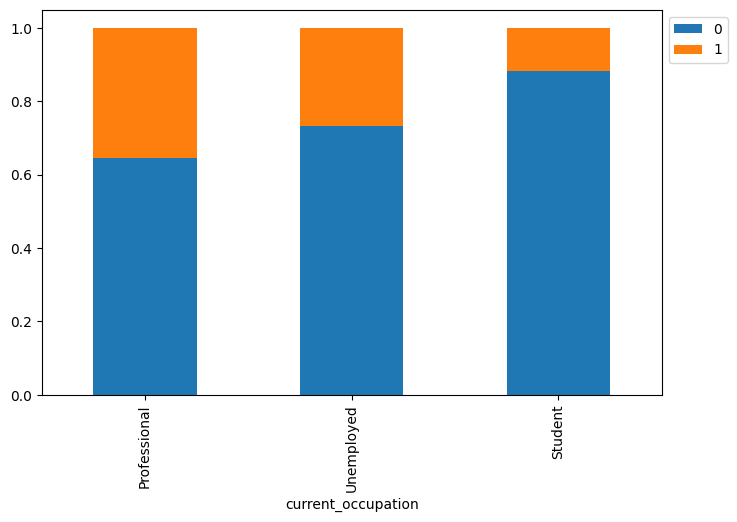

In [ ]:
stacked_barplot(df, "current_occupation", "status")

In [ ]:
conversion_by_occupation = df.groupby("current_occupation")["status"].mean().sort_values(ascending=False)
print("Conversion rate by current_occupation:")
print(conversion_by_occupation.round(4))

Conversion rate by current_occupation:
current_occupation
Professional    0.3551
Unemployed      0.2658
Student         0.1171
Name: status, dtype: float64


**Observation — `current_occupation` vs. conversion:** Conversion rate is highest for Professionals (35.51%), followed by the Unemployed (26.58%), and lowest for Students (11.71%). Professionals — likely the core reskilling/upskilling audience — convert at roughly 3x the rate of Students.

status                0     1   All
first_interaction                  
All                3235  1377  4612
Website            1383  1159  2542
Mobile App         1852   218  2070
------------------------------------------------------------------------------------------------------------------------


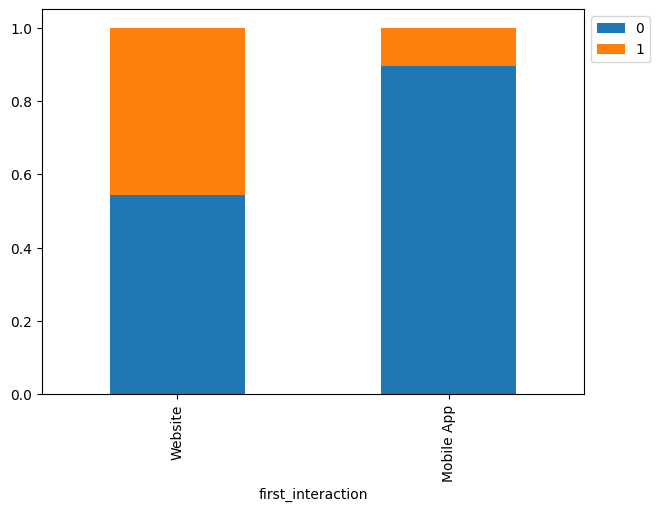

In [ ]:
stacked_barplot(df, "first_interaction", "status")

In [ ]:
conversion_by_first_interaction = df.groupby("first_interaction")["status"].mean().sort_values(ascending=False)
print("Conversion rate by first_interaction:")
print(conversion_by_first_interaction.round(4))

Conversion rate by first_interaction:
first_interaction
Website       0.4559
Mobile App    0.1053
Name: status, dtype: float64


**Observation — `first_interaction` vs. conversion:** This is one of the strongest categorical relationships found in the data. Leads whose first interaction was through the Website convert at 45.59%, versus only 10.53% for leads whose first interaction was through the Mobile App — over a 4x difference. First interaction channel appears to be a highly informative signal.

status                0     1   All
profile_completed                  
All                3235  1377  4612
High               1318   946  2264
Medium             1818   423  2241
Low                  99     8   107
------------------------------------------------------------------------------------------------------------------------


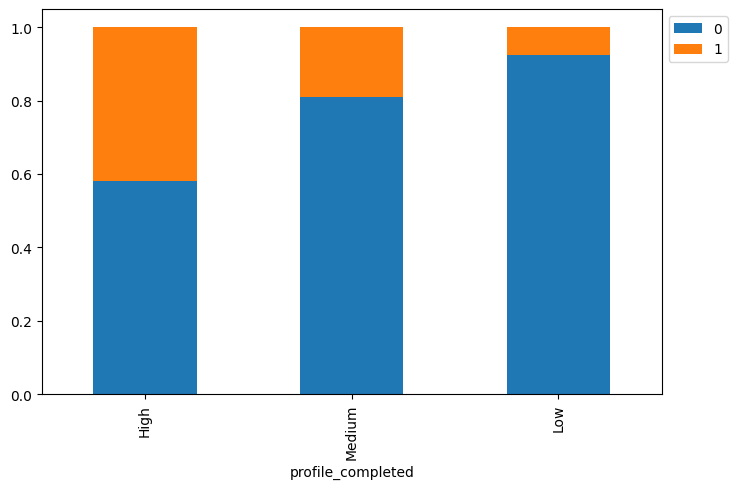

In [ ]:
stacked_barplot(df, "profile_completed", "status")

In [ ]:
conversion_by_profile = df.groupby("profile_completed")["status"].mean().sort_values(ascending=False)
print("Conversion rate by profile_completed:")
print(conversion_by_profile.round(4))

Conversion rate by profile_completed:
profile_completed
High      0.4178
Medium    0.1888
Low       0.0748
Name: status, dtype: float64


**Observation — `profile_completed` vs. conversion:** There is a clear, monotonic relationship: High profile completion converts at 41.78%, Medium at 18.88%, and Low at only 7.48%. The more a lead completes their profile, the more likely they are to convert — this is one of the most consistent patterns in the dataset.

status               0     1   All
last_activity                     
All               3235  1377  4612
Email Activity    1587   691  2278
Website Activity   677   423  1100
Phone Activity     971   263  1234
------------------------------------------------------------------------------------------------------------------------


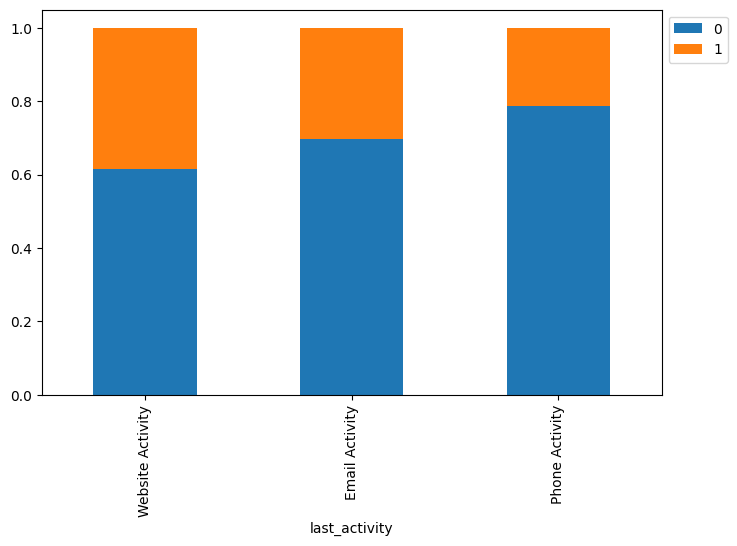

In [ ]:
stacked_barplot(df, "last_activity", "status")

In [ ]:
conversion_by_last_activity = df.groupby("last_activity")["status"].mean().sort_values(ascending=False)
print("Conversion rate by last_activity:")
print(conversion_by_last_activity.round(4))

Conversion rate by last_activity:
last_activity
Website Activity    0.3845
Email Activity      0.3033
Phone Activity      0.2131
Name: status, dtype: float64


**Observation — `last_activity` vs. conversion:** Leads whose last recorded activity was Website Activity convert at the highest rate (38.45%), followed by Email Activity (30.33%), with Phone Activity converting lowest (21.31%). Despite Email Activity being the most *common* last activity overall, Website Activity is the more *predictive* one for conversion.

#### Marketing-Channel Exposure vs. `status` (Conversion Rate)

In [ ]:
# Conversion rate (Yes vs. No) for each marketing-channel exposure flag
marketing_conversion = pd.DataFrame({
    flag: df.groupby(flag)["status"].mean()
    for flag in marketing_flags
}).T

marketing_conversion.columns = ["Conversion Rate (No)", "Conversion Rate (Yes)"]
marketing_conversion = marketing_conversion.round(4)
marketing_conversion

,Conversion Rate (No),Conversion Rate (Yes)
print_media_type1,0.2960,0.3199
print_media_type2,0.2973,0.3219
digital_media,0.2960,0.3188
educational_channels,0.3020,0.2794
referral,0.2908,0.6774


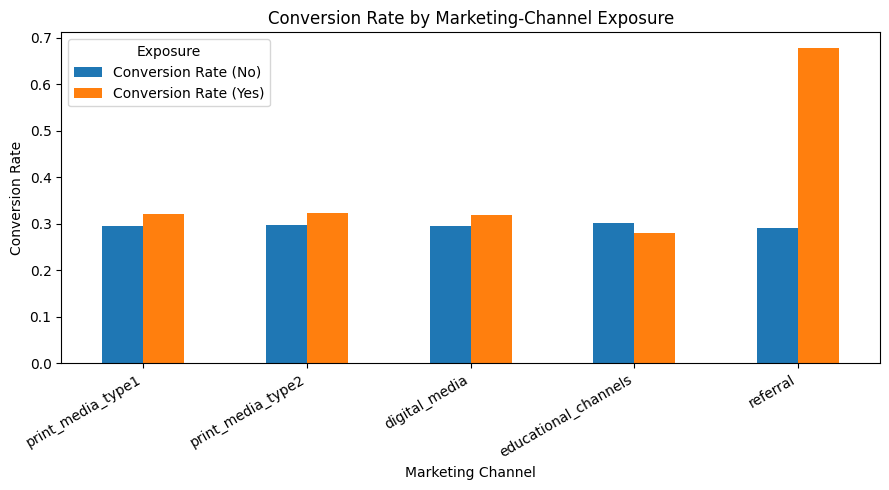

In [ ]:
# Visualizing conversion rate by exposure (Yes vs No) across all marketing channels
marketing_conversion.plot(kind="bar", figsize=(9, 5))
plt.title("Conversion Rate by Marketing-Channel Exposure")
plt.ylabel("Conversion Rate")
plt.xlabel("Marketing Channel")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Exposure")
plt.tight_layout()
plt.show()

**Observation — Marketing-channel exposure vs. conversion:** `print_media_type1`, `print_media_type2`, and `digital_media` show only small conversion-rate differences between "Yes" and "No" exposure (roughly 29-30% vs. 32%), and `educational_channels` shows almost no difference (30.2% "No" vs. 27.9% "Yes"). `referral`, however, stands out sharply: leads exposed via referral convert at 67.74%, more than double the 29.08% rate for leads without a referral — by far the strongest marketing-channel signal in the dataset, even though referred leads are a small share (93 of 4,612) of the overall population.

## Key EDA Insights

**Overall conversion:**
- Of 4,612 leads, **29.86% converted** to paid customers (1,377 converted vs. 3,235 not converted) — a moderately imbalanced target that will need to be handled carefully when choosing an evaluation metric later.

**Numerical behavior — what distinguishes converted leads:**
- **`time_spent_on_website` shows the clearest numerical difference**: converted leads spend nearly double the time on the site (median 789s vs. 317s; mean 1,068s vs. 577s). This is the strongest numerical engagement signal found.
- **`age`** also differs meaningfully — converted leads are older on average (median 54 vs. 49), consistent with ExtraaLearn's focus on working professionals.
- **`website_visits`** and **`page_views_per_visit`** show little to no difference between converted and non-converted leads (near-identical medians/means for both). Simply visiting more often or viewing more pages per visit is not, by itself, a strong signal — the *quality*/*duration* of engagement (time spent) matters more than the *frequency* of visits.

**Categorical behavior — what distinguishes converted leads:**
- **`first_interaction`** is one of the strongest predictors found: leads who first interacted via the **Website convert at 45.59%**, more than 4x the **10.53% conversion rate for Mobile App** leads.
- **`profile_completed`** shows a clear, monotonic relationship with conversion: **High (41.78%) > Medium (18.88%) > Low (7.48%)**. Profile completion appears to be a strong, actionable engagement signal.
- **`current_occupation`** matters: **Professionals convert at 35.51%**, nearly 3x the rate of **Students (11.71%)**, with **Unemployed leads in between (26.58%)**.
- **`last_activity`** also differentiates leads: **Website Activity (38.45%)** converts better than **Email Activity (30.33%)** or **Phone Activity (21.31%)**, even though Email Activity is the most *frequent* last activity overall — the type of last touchpoint matters more than its frequency.
- Among the marketing-exposure flags, most (`print_media_type1`, `print_media_type2`, `digital_media`, `educational_channels`) show only small differences in conversion rate between "Yes" and "No" exposure (roughly 28–32% either way). **`referral` is a clear exception** — referred leads convert at **67.74%**, more than double the 29.08% baseline — though referrals are a small slice of the lead base (only 93 of 4,612 leads).

**Data-quality / imbalance notes carried into preprocessing:**
- The marketing-exposure flags are all heavily imbalanced toward "No" (e.g., only 93 of 4,612 leads have `referral` = "Yes"), so their conversion-rate differences should be interpreted with that small sample size in mind.
- `website_visits` and `page_views_per_visit` both contain a right-skewed tail with some values flagged by the IQR method as statistical outliers (from the earlier Data Overview step) — these will be assessed (not blindly removed) in the upcoming Outlier Check step, since they may reflect a genuine subgroup of highly engaged leads rather than data errors.

These patterns point toward **website-originated, highly engaged, profile-complete leads — especially those with a referral source — as the profile most likely to convert**, which will be explored further and validated with modeling in the next steps.

# **Data Preprocessing**

## Outlier Check

In [ ]:
# IQR-based outlier detection for the key numerical variables
numerical_features_check = ["age", "website_visits", "time_spent_on_website", "page_views_per_visit"]

outlier_summary_rows = []
for col in numerical_features_check:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    pct_outliers = 100 * n_outliers / len(df)
    outlier_summary_rows.append({
        "Feature": col,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Num Outliers": n_outliers,
        "Pct Outliers": round(pct_outliers, 2),
    })

outlier_summary = pd.DataFrame(outlier_summary_rows)
outlier_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Num Outliers,Pct Outliers
0,age,36.00,57.00,21.00,4.50,88.50,0,0.00
1,website_visits,2.00,5.00,3.00,-2.50,9.50,154,3.34
2,time_spent_on_website,148.75,1336.75,1188.00,-1633.25,3118.75,0,0.00
3,page_views_per_visit,2.08,3.76,1.68,-0.44,6.27,257,5.57


**Outlier findings (from the table above):**
- `age`: IQR bounds are [4.5, 88.5]. **0 outliers (0.00%)** — every lead's age falls comfortably within the fence.
- `website_visits`: IQR bounds are [-2.5, 9.5] (effectively, upper bound only since visits can't be negative). **154 outliers (3.34%)** — leads visiting the site more than ~9-10 times.
- `time_spent_on_website`: IQR bounds are [-1633.25, 3118.75]. **0 outliers (0.00%)** — despite the wide spread seen in the univariate histogram, no points fall outside the (very wide) IQR fence.
- `page_views_per_visit`: IQR bounds are [-0.44, 6.27]. **257 outliers (5.57%)** — leads viewing more than ~6.3 pages per visit on average.

Only `website_visits` and `page_views_per_visit` have any IQR-flagged points, and in both cases these are upper-tail, highly-engaged leads rather than implausible values.

### Outlier Treatment Decision

**Decision: Retain all observations as-is — no removal or capping/winsorizing of outliers.**

Rationale:

- **Business plausibility over statistical anomaly.** The IQR-flagged points in `website_visits` and `page_views_per_visit` are leads who visit the site unusually often or view an unusually high number of pages per visit. In a lead-conversion context, this is exactly the kind of highly engaged behavior the business cares about identifying — not a data-entry error. `age` and `time_spent_on_website` show 0% IQR-flagged outliers, so there is nothing to treat there in the first place.
- **No implausible values.** None of the four numerical variables contain negative values, values outside plausible human ranges (e.g., `age` stays within 18-63), or other signs of corrupted data. There is no independent evidence (data-entry error, duplicate, sentinel value) that these points are invalid.
- **Removing or capping these leads would destroy potentially predictive signal.** The bivariate EDA already showed that `time_spent_on_website` (which has essentially no IQR outliers) is one of the strongest engagement signals for conversion; artificially capping the related engagement variables (`website_visits`, `page_views_per_visit`) risks flattening a legitimate high-engagement subgroup that may be disproportionately likely to convert.
- **Model choice supports this decision.** Both models used in this project — **Random Forest** and **AdaBoost** — are tree-based ensembles that split on threshold values rather than relying on distances or linear combinations of raw feature magnitudes. Extreme values in a single feature do not distort the fitted splits or bias the loss function the way they would for a distance-based or linear model, so aggressive outlier treatment is not necessary for these two algorithms to perform well.
- **Trade-off acknowledged.** The alternative approaches were considered:
  - *Retaining (chosen):* preserves all signal; con — extreme values still exist in the data.
  - *Capping/winsorizing:* would reduce the influence of extreme points; con — since the models are tree-based, this mainly compresses information without materially changing splits, and risks understating genuinely high-engagement leads.
  - *Removing:* would discard ~3-6% of rows for two features; con — removes real leads (some of which may be converters) and is not justified without evidence they are erroneous.

No rows are dropped and no values are modified in this step. The complete, untreated dataset moves forward into the train/test split.

## Data Preparation for modeling

- We want to predict which lead is more likely to be converted.
- Before we proceed to build a model, we'll have to encode categorical features.
- We'll split the data into train and test to be able to evaluate the model that we build on the train data.

**Why `ID` is excluded from the predictor set:** `ID` is a unique identifier assigned to each lead (verified earlier: 4,612 unique values for 4,612 rows, with no duplicates). It carries no information about a lead's characteristics or behavior, and including it as a feature would either be ignored by the model or, worse, risk the model latching onto meaningless ID-ordering artifacts. `ID` is therefore dropped from the feature set `X` before any modeling, and is not passed into the preprocessing pipeline at all.

In [ ]:
# Defining the target and the feature set

# Target variable: status (already binary numeric: 0 = Not Converted, 1 = Converted)
y = df["status"].copy()

# Feature set: all columns except the identifier `ID` and the target `status`
X = df.drop(columns=["ID", "status"]).copy()

print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)
print()
print("Feature columns:")
print(list(X.columns))

Feature matrix X shape: (4612, 13)
Target vector y shape: (4612,)

Feature columns:
['age', 'current_occupation', 'first_interaction', 'profile_completed', 'website_visits', 'time_spent_on_website', 'page_views_per_visit', 'last_activity', 'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral']


In [ ]:
# Verifying the target is binary (0/1) and consistent with earlier EDA
print("Unique values in y:", sorted(y.unique()))
print()
print("Target class counts:")
print(y.value_counts())
print()
print("Target class proportions:")
print(y.value_counts(normalize=True).round(4))

Unique values in y: [np.int64(0), np.int64(1)]

Target class counts:
status
0    3235
1    1377
Name: count, dtype: int64

Target class proportions:
status
0    0.7014
1    0.2986
Name: proportion, dtype: float64


**Feature engineering decision:** No additional engineered features are introduced at this stage.

Rationale:
- The existing raw variables already capture the key behavioral and demographic signals identified during EDA (`time_spent_on_website`, `first_interaction`, `profile_completed`, `current_occupation`, `last_activity`, and the marketing-exposure flags all showed clear, interpretable relationships with `status` on their own).
- Simple derived combinations (e.g., summing the five Yes/No marketing flags into a single "total exposure" count) were considered, but EDA showed that four of the five flags (`print_media_type1`, `print_media_type2`, `digital_media`, `educational_channels`) have only a weak, inconsistent relationship with conversion, while `referral` behaves very differently (much higher conversion rate) — collapsing them into one combined feature would blur the one flag (`referral`) that is actually informative. Keeping them as separate one-hot-encoded features preserves this distinction and lets the tree-based models split on `referral` independently if useful.
- Random Forest and AdaBoost can naturally capture non-linear relationships and interactions between the existing raw features (e.g., between `profile_completed` and `first_interaction`) without needing them to be hand-engineered in advance.
- No engineered feature is created from `status` or from any information that would be unavailable at prediction time, so there is no risk of target leakage from this decision (since no new feature is created).

If a future iteration finds under-fitting, simple candidates like an ordinal encoding of `profile_completed` (Low < Medium < High) or an `age_group` bucket could be revisited — but they are not introduced now, since the current features are already sufficient and adding features without evidence of benefit would be feature engineering "for its own sake."

### Train-Test Split

The data is split into training and test sets **before any preprocessing is fit** (imputation, scaling, encoding). This ensures the test set remains a genuinely held-out sample: no statistic learned from it (feature means, categories, scaling parameters) leaks into training. `stratify=y` is used because the target is moderately imbalanced (~70% / 30%), and stratification ensures both the training and test sets preserve this same class balance, avoiding a split that happens to over- or under-represent converted leads by chance.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print()
print("Training target distribution:")
print(y_train.value_counts(normalize=True).round(4))
print()
print("Test target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training set shape: (3689, 13)
Test set shape: (923, 13)

Training target distribution:
status
0    0.7015
1    0.2985
Name: proportion, dtype: float64

Test target distribution:
status
0    0.701
1    0.299
Name: proportion, dtype: float64


**Note:** From this point forward, `X_test` / `y_test` are treated as untouched hold-out data. They will not be used again until the final model evaluation step — not for preprocessing fitting, not for hyperparameter tuning, and not for feature selection.

## **Data Pre-processing Pipeline**

In [ ]:
# Programmatically identify numerical and categorical feature columns from X
# (rather than hard-coding, in case column dtypes or names ever change)
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['age', 'website_visits', 'time_spent_on_website', 'page_views_per_visit']
Categorical features: ['current_occupation', 'first_interaction', 'profile_completed', 'last_activity', 'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral']


**Preprocessing pipeline design:**

- **Numerical features** (`age`, `website_visits`, `time_spent_on_website`, `page_views_per_visit`): a `SimpleImputer` (median strategy) is included defensively — the current training data has no missing values (confirmed in the Data Overview step), but this makes the pipeline robust to any missing values that might appear in future inference data. A `StandardScaler` is also included for pipeline consistency and to keep the preprocessing reusable if a non-tree model (e.g., Logistic Regression) is added later; however, **Random Forest and AdaBoost do not require feature scaling** — they split on raw threshold values per feature, so scaling does not change the trees' structure or performance. It is included here purely for pipeline generality, not because these two models need it.
- **Categorical features** (`current_occupation`, `first_interaction`, `profile_completed`, `last_activity`, and the five marketing-exposure flags): a `SimpleImputer` (most-frequent strategy) is included for the same defensive reason as above, followed by `OneHotEncoder(handle_unknown="ignore")`. `handle_unknown="ignore"` ensures that if a category not seen during training appears at inference time, the pipeline will not raise an error — it will simply encode it as all-zeros for that feature's dummy columns.
- All of this is assembled with `ColumnTransformer` inside a single `Pipeline` object, so that **fitting only ever happens on `X_train`**. The transformer's learned statistics (medians, most-frequent categories, one-hot categories, scaling parameters) all come exclusively from the training data — the test set is only ever `.transform()`-ed, never used to `.fit()` anything, which prevents data leakage.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical pipeline: defensive median imputation + scaling
# (scaling included for pipeline generality; not required by Random Forest/AdaBoost)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categorical pipeline: defensive most-frequent imputation + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# Combine into a single ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features),
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'website_visits',
                                  'time_spent_on_website',
                                  'page_views_per_visit']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['current_occupation', 'first_interaction',
                                  'profile_completed', 'last_activity',
                                  'print_media_type1', 'print_media_type2',
                                  'digital_media', 'educational_channels',
                                  'referral'])])

In [ ]:
# Fit the preprocessor on the TRAINING data only, then transform both train and test sets
# (this is a validation check of the pipeline design; the same `preprocessor` object will be
# re-used inside the full model pipelines in the Model Building section)
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("Transformed training set shape:", X_train_transformed.shape)
print("Transformed test set shape:", X_test_transformed.shape)
print()
print("Number of features after encoding:", X_train_transformed.shape[1])
print("Feature names after preprocessing:")
print(preprocessor.get_feature_names_out())

Transformed training set shape: (3689, 25)
Transformed test set shape: (923, 25)

Number of features after encoding: 25
Feature names after preprocessing:
['num__age' 'num__website_visits' 'num__time_spent_on_website'
 'num__page_views_per_visit' 'cat__current_occupation_Professional'
 'cat__current_occupation_Student' 'cat__current_occupation_Unemployed'
 'cat__first_interaction_Mobile App' 'cat__first_interaction_Website'
 'cat__profile_completed_High' 'cat__profile_completed_Low'
 'cat__profile_completed_Medium' 'cat__last_activity_Email Activity'
 'cat__last_activity_Phone Activity' 'cat__last_activity_Website Activity'
 'cat__print_media_type1_No' 'cat__print_media_type1_Yes'
 'cat__print_media_type2_No' 'cat__print_media_type2_Yes'
 'cat__digital_media_No' 'cat__digital_media_Yes'
 'cat__educational_channels_No' 'cat__educational_channels_Yes'
 'cat__referral_No' 'cat__referral_Yes']


**Validation of the preprocessing design:** The transformed training and test matrices have the same number of columns, confirming the encoder learned a consistent, fixed feature space from the training data alone (with `handle_unknown="ignore"` protecting the test transform from any category not seen in training). This `preprocessor` object will be embedded directly inside each model's `Pipeline` in the Model Building section, so that preprocessing is refit correctly inside cross-validation and hyperparameter tuning folds — never fit once on the whole dataset up front.

# **Model Building**

## Model Evaluation Criterion

ExtraaLearn's business goal is to identify which leads are likely to convert so sales effort can be focused on them. The target is moderately imbalanced (**29.86% converted vs. 70.14% not converted**, confirmed in the Data Overview step), so **accuracy alone would be misleading** — a model that predicts "not converted" for every lead would already score ~70% accuracy while being completely useless for the business.

To choose the right metric, consider the cost of each error type:
- **False Negative** (predicting a lead won't convert when it actually would): the sales team never follows up with this lead, and a genuine paying customer is missed entirely. This is a lost-revenue error.
- **False Positive** (predicting a lead will convert when it actually won't): the sales team spends outreach time/resources on a lead that doesn't pay off. This is a wasted-effort error, but a comparatively cheaper one than losing a real customer.

Because **missing a genuine converter (False Negative) is more costly to the business than spending some extra effort on a lead who doesn't convert (False Positive)**, the model should be biased toward catching as many true converters as possible.

**Primary metric: Recall (of the "converted" / positive class).** Recall directly measures the fraction of actual converters the model successfully identifies, which is exactly what the business needs to prioritize outreach effectively.

**Secondary metrics reported alongside Recall:**
- **Precision** — of the leads the model flags as likely converters, how many actually convert; keeps an eye on how much wasted effort the recall-focused approach creates.
- **F1-score** — the harmonic mean of precision and recall, useful as a single balanced check that recall isn't being maximized at an unreasonable cost to precision.
- **Accuracy** — reported for completeness, but explicitly not the primary metric given the class imbalance.
- **ROC-AUC** — measures how well the model ranks converted leads above non-converted leads across all classification thresholds, independent of any single threshold choice; useful as a threshold-independent measure of overall discriminative power, and important since the final deployed system may want to rank/prioritize leads rather than just output a hard 0/1 label.

**Recall will be used consistently as the primary metric to compare Random Forest and AdaBoost, both at baseline and after hyperparameter tuning.**

## Define functions for Model Evaluation

In [ ]:
# Function to compute different metrics to check performance of a classification model
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classifier model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # If the model supports predict_proba, also compute ROC-AUC using the predicted
    # probability of the positive class (status = 1). This extends the original
    # function without changing its existing behavior/return columns for callers
    # that don't need ROC-AUC.
    roc_auc = np.nan
    if hasattr(model, "predict_proba"):
        pred_proba = model.predict_proba(predictors)[:, 1]
        roc_auc = roc_auc_score(target, pred_proba)

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
            "ROC-AUC": roc_auc,
        },
        index=[0],
    )

    return df_perf

## Random Forest Model

In [ ]:
# Baseline Random Forest pipeline: preprocessing (from Step 4) + classifier
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42)),
])

rf_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'website_visits',
                                                   'time_spent_on_website',
                                                   'page_views_per_visit']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['current_occupation',
                                                   'first_interaction',
                                                   'profile_completed',
                                                   'last_activity',
                                                   'print_media_type1',
                                                   'print_media_type2',
                                                   'digital_media',
                                                   'educational_channels',
                                                   'referral'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

**Cross-validation (training data only):** 5-fold stratified cross-validation is used to get a robust, low-variance estimate of the Random Forest's Recall before touching the test set. Because the pipeline includes the preprocessing `ColumnTransformer`, preprocessing is refit independently within each fold — the fold held out for validation never influences the fold(s) used for fitting, avoiding any leakage even during cross-validation.

In [ ]:
# 5-fold stratified cross-validation on the TRAINING set only, scored on Recall (primary metric)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_scores = cross_val_score(
    rf_pipeline, X_train, y_train, cv=cv_strategy, scoring="recall"
)

print("Random Forest CV Recall scores (per fold):", np.round(rf_cv_scores, 4))
print(f"Random Forest mean CV Recall: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

Random Forest CV Recall scores (per fold): [0.7273 0.7227 0.7    0.7376 0.7045]
Random Forest mean CV Recall: 0.7184 (+/- 0.0141)


### Checking model performance on training set

In [ ]:
# Fit the baseline Random Forest pipeline on the training data
rf_pipeline.fit(X_train, y_train)

# Performance on the TRAINING set (to later compare against test-set performance for overfitting signs)
rf_train_perf = model_performance_classification(rf_pipeline, X_train, y_train)
print("Random Forest — Training set performance:")
rf_train_perf

Random Forest — Training set performance:


,Accuracy,Recall,Precision,F1,ROC-AUC
0,0.999729,1.0,0.999093,0.999546,0.999965


### Checking model performance on test set

In [ ]:
# Performance on the held-out TEST set
rf_test_perf = model_performance_classification(rf_pipeline, X_test, y_test)
print("Random Forest — Test set performance:")
rf_test_perf

Random Forest — Test set performance:


,Accuracy,Recall,Precision,F1,ROC-AUC
0,0.856988,0.717391,0.785714,0.75,0.91665


In [ ]:
# Detailed classification report on the test set
rf_test_pred = rf_pipeline.predict(X_test)
print("Random Forest — Classification Report (Test Set):")
print(classification_report(y_test, rf_test_pred, target_names=["Not Converted", "Converted"]))

Random Forest — Classification Report (Test Set):
               precision    recall  f1-score   support

Not Converted       0.88      0.92      0.90       647
    Converted       0.79      0.72      0.75       276

     accuracy                           0.86       923
    macro avg       0.83      0.82      0.82       923
 weighted avg       0.85      0.86      0.86       923



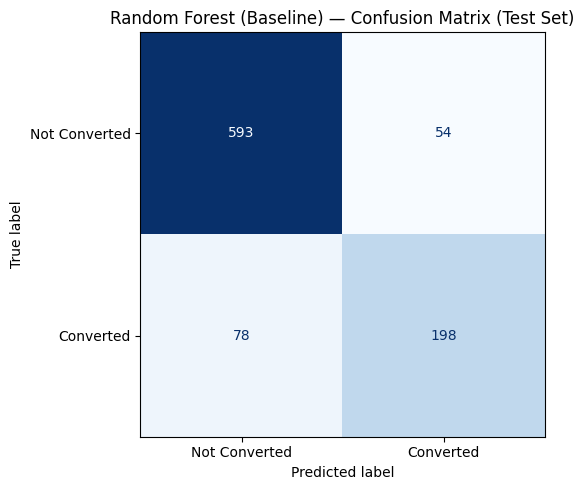

In [ ]:
# Confusion matrix visualization (test set)
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, rf_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Converted", "Converted"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Random Forest (Baseline) — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

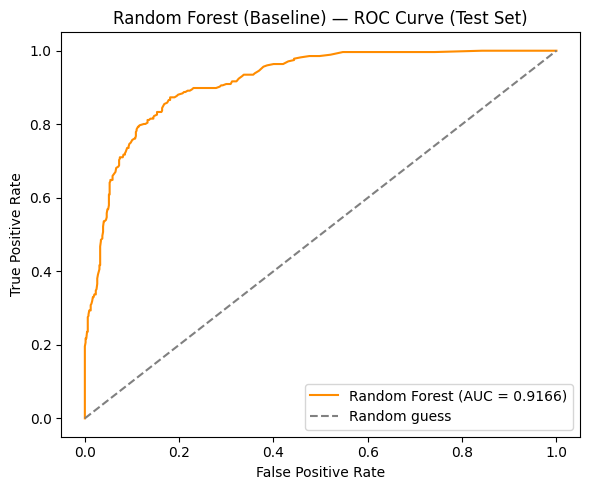

Random Forest Test ROC-AUC: 0.9166


In [ ]:
# ROC curve and ROC-AUC (test set)
rf_test_proba = rf_pipeline.predict_proba(X_test)[:, 1]
rf_roc_auc = roc_auc_score(y_test, rf_test_proba)
fpr, tpr, _ = roc_curve(y_test, rf_test_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {rf_roc_auc:.4f})", color="darkorange")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest (Baseline) — ROC Curve (Test Set)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Random Forest Test ROC-AUC: {rf_roc_auc:.4f}")

In [ ]:
# Results table: baseline Random Forest
results_table = pd.DataFrame([{
    "Model": "Random Forest (Baseline)",
    "CV Recall (mean)": round(rf_cv_scores.mean(), 4),
    "Accuracy": round(rf_test_perf["Accuracy"].iloc[0], 4),
    "Precision": round(rf_test_perf["Precision"].iloc[0], 4),
    "Recall": round(rf_test_perf["Recall"].iloc[0], 4),
    "F1": round(rf_test_perf["F1"].iloc[0], 4),
    "ROC-AUC": round(rf_test_perf["ROC-AUC"].iloc[0], 4),
}])

results_table

,Model,CV Recall (mean),Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest (Baseline),0.7184,0.857,0.7857,0.7174,0.75,0.9166


**Interpretation (Random Forest baseline):**

- **Cross-validation vs. test performance:** 5-fold CV Recall on the training data averaged **0.7184** (fold scores ranging 0.70-0.74, so reasonably stable across folds). On the held-out test set, Recall came in at **0.7174** — essentially identical to the CV estimate. This consistency between CV and test Recall is a good sign that the CV procedure gives a trustworthy estimate of out-of-sample performance for this metric.
- **Test-set metrics:** Accuracy 0.857, Precision 0.786, Recall 0.717, F1 0.75, ROC-AUC 0.917. The ROC-AUC of 0.917 indicates strong overall discriminative power — the model ranks converted leads above non-converted leads correctly in the large majority of cases.
- **Performance on converted leads specifically:** from the classification report, the "Converted" class has precision 0.79 and recall 0.72 (support 276 leads). This means the model correctly identifies about 72% of actual converters, and when it predicts "will convert," it's right about 79% of the time.
- **Precision/Recall trade-off:** Precision (0.79) is somewhat higher than Recall (0.72) at the model's default 0.5 threshold, meaning the model is currently a bit conservative about flagging leads as likely converters. Since Recall was chosen as the primary business metric (missing a genuine converter is costlier than a wasted follow-up), this suggests there may be room to shift the decision threshold — or tune the model — to trade a bit of precision for higher recall, which will be explored in the hyperparameter tuning step.
- **Clear evidence of overfitting:** The training-set performance is essentially perfect (Accuracy 0.9997, Recall 1.0, ROC-AUC 0.99997), while test-set performance is much lower (Accuracy 0.857, Recall 0.717, ROC-AUC 0.917). This large gap between training and test performance is a classic sign that the untuned Random Forest (200 fully-grown trees, no depth/leaf constraints) has memorized the training data rather than purely learning generalizable patterns. This does not necessarily make the model unusable — the CV and test Recall values agree closely, so the *generalization* estimate itself is trustworthy — but it does flag `max_depth`, `min_samples_leaf`, and `min_samples_split` as prime candidates for hyperparameter tuning to reduce overfitting.
- **Overall assessment for the business objective:** As a first baseline, this Random Forest is a reasonable starting point — a Recall of ~0.72 and ROC-AUC of ~0.92 means it can meaningfully help prioritize leads for outreach. It should **not** yet be treated as the final or best model: the overfitting signal and the precision/recall trade-off both suggest hyperparameter tuning (Step 6) may improve generalization and better align the model with the business preference for high recall.

## AdaBoost Classifier

In [ ]:
# Baseline AdaBoost pipeline: SAME preprocessing (from Step 4) + AdaBoostClassifier
ada_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", AdaBoostClassifier(n_estimators=100, random_state=42)),
])

ada_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'website_visits',
                                                   'time_spent_on_website',
                                                   'page_views_per_visit']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['current_occupation',
                                                   'first_interaction',
                                                   'profile_completed',
                                                   'last_activity',
                                                   'print_media_type1',
                                                   'print_media_type2',
                                                   'digital_media',
                                                   'educational_channels',
                                                   'referral'])])),
                ('model',
                 AdaBoostClassifier(n_estimators=100, random_state=42))])

**Cross-validation (training data only):** Using the same evaluation methodology as the Random Forest baseline — 5-fold stratified cross-validation on `X_train`/`y_train` only, scored on Recall — so the two baselines are directly comparable. The preprocessing `ColumnTransformer` is refit independently within each fold since it lives inside the pipeline, preventing leakage.

In [ ]:
# 5-fold stratified cross-validation on the TRAINING set only, scored on Recall (primary metric)
# Reusing the same cv_strategy object defined in the Random Forest section for a consistent comparison
ada_cv_scores = cross_val_score(
    ada_pipeline, X_train, y_train, cv=cv_strategy, scoring="recall"
)

print("AdaBoost CV Recall scores (per fold):", np.round(ada_cv_scores, 4))
print(f"AdaBoost mean CV Recall: {ada_cv_scores.mean():.4f} (+/- {ada_cv_scores.std():.4f})")

AdaBoost CV Recall scores (per fold): [0.6455 0.6409 0.6364 0.6063 0.6318]
AdaBoost mean CV Recall: 0.6322 (+/- 0.0137)


### Checking model performance on training set

In [ ]:
# Fit the baseline AdaBoost pipeline on the training data
ada_pipeline.fit(X_train, y_train)

# Performance on the TRAINING set (to compare against test-set performance for overfitting signs)
ada_train_perf = model_performance_classification(ada_pipeline, X_train, y_train)
print("AdaBoost — Training set performance:")
ada_train_perf

AdaBoost — Training set performance:


,Accuracy,Recall,Precision,F1,ROC-AUC
0,0.833288,0.675749,0.742515,0.707561,0.893494


### Checking model performance on test set

In [ ]:
# Performance on the held-out TEST set
ada_test_perf = model_performance_classification(ada_pipeline, X_test, y_test)
print("AdaBoost — Test set performance:")
ada_test_perf

AdaBoost — Test set performance:


,Accuracy,Recall,Precision,F1,ROC-AUC
0,0.832069,0.692029,0.731801,0.711359,0.900533


In [ ]:
# Detailed classification report on the test set
ada_test_pred = ada_pipeline.predict(X_test)
print("AdaBoost — Classification Report (Test Set):")
print(classification_report(y_test, ada_test_pred, target_names=["Not Converted", "Converted"]))

AdaBoost — Classification Report (Test Set):
               precision    recall  f1-score   support

Not Converted       0.87      0.89      0.88       647
    Converted       0.73      0.69      0.71       276

     accuracy                           0.83       923
    macro avg       0.80      0.79      0.80       923
 weighted avg       0.83      0.83      0.83       923



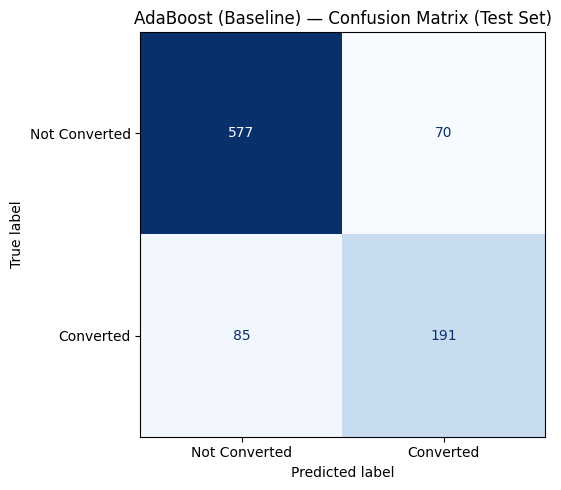

In [ ]:
# Confusion matrix visualization (test set)
fig, ax = plt.subplots(figsize=(6, 5))
cm_ada = confusion_matrix(y_test, ada_test_pred)
disp_ada = ConfusionMatrixDisplay(confusion_matrix=cm_ada, display_labels=["Not Converted", "Converted"])
disp_ada.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("AdaBoost (Baseline) — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

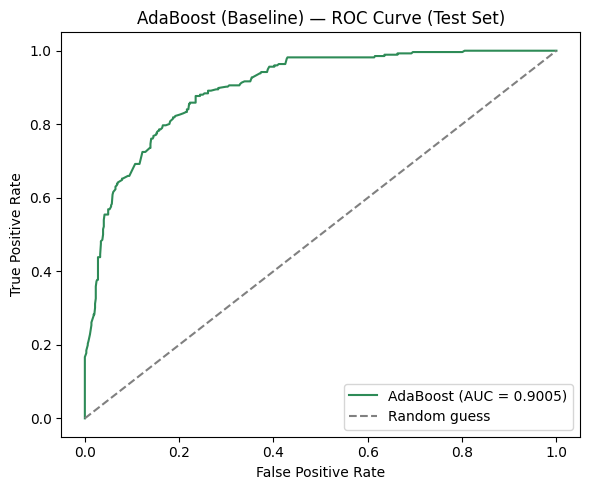

AdaBoost Test ROC-AUC: 0.9005


In [ ]:
# ROC curve and ROC-AUC (test set)
ada_test_proba = ada_pipeline.predict_proba(X_test)[:, 1]
ada_roc_auc = roc_auc_score(y_test, ada_test_proba)
fpr_ada, tpr_ada, _ = roc_curve(y_test, ada_test_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost (AUC = {ada_roc_auc:.4f})", color="seagreen")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AdaBoost (Baseline) — ROC Curve (Test Set)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"AdaBoost Test ROC-AUC: {ada_roc_auc:.4f}")

In [ ]:
# Append AdaBoost results to the shared model-comparison results table
ada_results_row = pd.DataFrame([{
    "Model": "AdaBoost (Baseline)",
    "CV Recall (mean)": round(ada_cv_scores.mean(), 4),
    "Accuracy": round(ada_test_perf["Accuracy"].iloc[0], 4),
    "Precision": round(ada_test_perf["Precision"].iloc[0], 4),
    "Recall": round(ada_test_perf["Recall"].iloc[0], 4),
    "F1": round(ada_test_perf["F1"].iloc[0], 4),
    "ROC-AUC": round(ada_test_perf["ROC-AUC"].iloc[0], 4),
}])

results_table = pd.concat([results_table, ada_results_row], ignore_index=True)
results_table

,Model,CV Recall (mean),Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest (Baseline),0.7184,0.8570,0.7857,0.7174,0.7500,0.9166
1,AdaBoost (Baseline),0.6322,0.8321,0.7318,0.6920,0.7114,0.9005


**Interpretation and comparison to the Random Forest baseline:**

- **CV Recall:** Random Forest CV Recall (0.7184) is notably higher than AdaBoost CV Recall (**0.6322**). AdaBoost's fold scores (0.61-0.65) are also all below the Random Forest range (0.70-0.74) — Random Forest wins on CV Recall.
- **Test Recall:** Random Forest test Recall (0.7174) is again higher than AdaBoost test Recall (**0.6920**). Random Forest wins on test Recall as well.
- **Precision / F1 / ROC-AUC:** Random Forest also leads on every secondary metric — Precision (0.786 vs. 0.732), F1 (0.750 vs. 0.711), and ROC-AUC (0.917 vs. 0.901). AdaBoost is not competitive with Random Forest on any of the five metrics at baseline settings.
- **Overfitting comparison:** AdaBoost shows **much less train/test gap** than Random Forest. AdaBoost's training performance (Accuracy 0.833, Recall 0.676, ROC-AUC 0.893) is close to its test performance (Accuracy 0.832, Recall 0.692, ROC-AUC 0.901) — almost no overfitting, consistent with AdaBoost's shallow "stump"-style weak learners providing a natural regularizing effect. This is in contrast to the Random Forest baseline, which was essentially memorizing the training set (Recall 1.0 on train vs. 0.717 on test).
- **Which model looks more promising before tuning:** **Random Forest currently performs better on every metric that matters for this business problem**, including the primary metric (Recall) and ROC-AUC. AdaBoost's advantage is that it generalizes with almost no overfitting, but its absolute performance is still lower than Random Forest's on both CV and test Recall. Since Random Forest's CV and test Recall already agree closely with each other (0.7184 vs. 0.7174) despite the training-set overfitting, the overfitting on the *training set* does not appear to be hurting Random Forest's *actual generalization* — it's simply fitting the training data very tightly while still generalizing about as well as, and currently better than, AdaBoost.
- **Bottom line:** At baseline settings, **Random Forest is the more promising model**. Both baselines will go through hyperparameter tuning in the next step, which may narrow the gap (or change the picture) — no final model selection is made yet.

# **Model Performance Improvement - Hyperparameter Tuning**

**Tuning methodology (applies to both models below):**

- Hyperparameter search is performed using **only `X_train` / `y_train`**, with 5-fold `StratifiedKFold(shuffle=True, random_state=42)` — the exact same cross-validation setup used for the baselines, so tuned CV scores are directly comparable to baseline CV scores.
- The scoring metric is **`scoring="recall"`**, consistent with the primary business metric established in Step 5.
- **`X_test` / `y_test` are not touched at any point during the search.** Each tuned model is evaluated on the test set exactly once, after the search has already selected its best estimator — never during or to guide the search.
- The correct sequence followed here is: **Training data → CV / hyperparameter search → select best estimator → one final evaluation on the untouched test set.**

**Random Forest search space rationale:** The baseline Random Forest showed severe training-set overfitting (train Recall 1.0 vs. test Recall 0.717), so tuning targets the parameters that most directly control tree complexity and overfitting: `max_depth`, `min_samples_split`, and `min_samples_leaf` constrain how deep/specific individual trees can grow; `max_features` controls how much feature randomness is injected per split (more randomness = more regularization, potentially at some cost to fit); `n_estimators` is included at modest values since more trees generally stabilizes the ensemble without much added overfitting risk. The full grid below has 2 × 4 × 3 × 3 × 2 = 144 combinations — too many to exhaustively search in a reasonable time academically, so `RandomizedSearchCV` is used with a fixed `random_state=42` and a modest `n_iter` for a reproducible, defensible search rather than an exhaustive one.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Compact, defensible search space targeting Random Forest overfitting
param_dist_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, 15, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist_rf,
    n_iter=25,
    scoring="recall",
    cv=cv_strategy,          # same StratifiedKFold(n_splits=5, shuffle=True, random_state=42) as baselines
    random_state=42,
    n_jobs=-1,
    refit=True,
)

# Fit the search using ONLY the training data
rf_random_search.fit(X_train, y_train)

print("Random Forest — Best parameters found:")
print(rf_random_search.best_params_)
print()
print(f"Random Forest — Best CV Recall: {rf_random_search.best_score_:.4f}")
print(f"Number of CV folds used: {cv_strategy.get_n_splits()}")

Random Forest — Best parameters found:
{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}

Random Forest — Best CV Recall: 0.7311
Number of CV folds used: 5


In [ ]:
# Best estimator identified by the search (already refit on the full X_train, y_train)
rf_tuned_pipeline = rf_random_search.best_estimator_
rf_tuned_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'website_visits',
                                                   'time_spent_on_website',
                                                   'page_views_per_visit']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['current_occupation',
                                                   'first_interaction',
                                                   'profile_completed',
                                                   'last_activity',
                                                   'print_media_type1',
                                                   'print_media_type2',
                                                   'digital_media',
                                                   'educational_channels',
                                                   'referral'])])),
                ('model',
                 RandomForestClassifier(min_samples_split=5, random_state=42))])

### Checking model performance on training set

In [ ]:
# Tuned Random Forest performance on the TRAINING set (to check the overfitting gap post-tuning)
rf_tuned_train_perf = model_performance_classification(rf_tuned_pipeline, X_train, y_train)
print("Random Forest (Tuned) — Training set performance:")
rf_tuned_train_perf

Random Forest (Tuned) — Training set performance:


,Accuracy,Recall,Precision,F1,ROC-AUC
0,0.970453,0.933697,0.966165,0.949654,0.997416


### Checking model performance on test set

In [ ]:
# Single, final evaluation of the tuned Random Forest on the untouched TEST set
rf_tuned_test_perf = model_performance_classification(rf_tuned_pipeline, X_test, y_test)
print("Random Forest (Tuned) — Test set performance:")
rf_tuned_test_perf

Random Forest (Tuned) — Test set performance:


,Accuracy,Recall,Precision,F1,ROC-AUC
0,0.861322,0.721014,0.796,0.756654,0.923213


In [ ]:
rf_tuned_test_pred = rf_tuned_pipeline.predict(X_test)
print("Random Forest (Tuned) — Classification Report (Test Set):")
print(classification_report(y_test, rf_tuned_test_pred, target_names=["Not Converted", "Converted"]))

Random Forest (Tuned) — Classification Report (Test Set):
               precision    recall  f1-score   support

Not Converted       0.89      0.92      0.90       647
    Converted       0.80      0.72      0.76       276

     accuracy                           0.86       923
    macro avg       0.84      0.82      0.83       923
 weighted avg       0.86      0.86      0.86       923



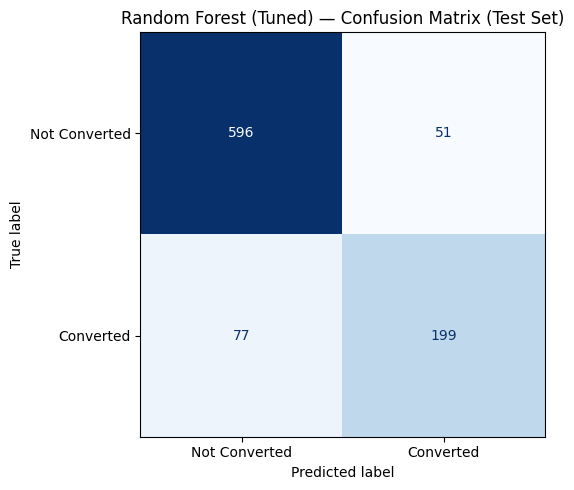

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_rf_tuned = confusion_matrix(y_test, rf_tuned_test_pred)
disp_rf_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_rf_tuned, display_labels=["Not Converted", "Converted"])
disp_rf_tuned.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Random Forest (Tuned) — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

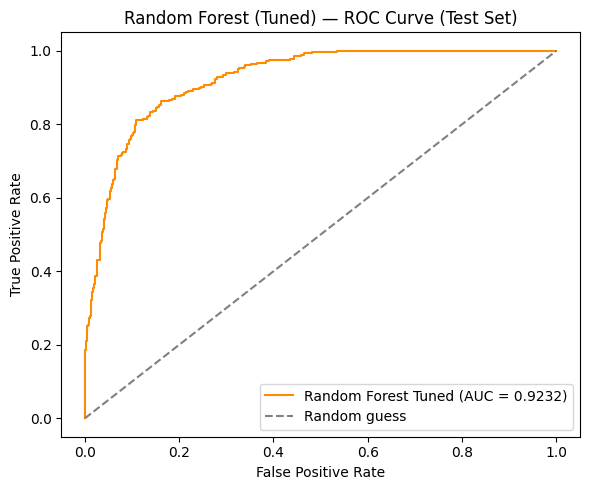

Random Forest (Tuned) Test ROC-AUC: 0.9232


In [ ]:
rf_tuned_test_proba = rf_tuned_pipeline.predict_proba(X_test)[:, 1]
rf_tuned_roc_auc = roc_auc_score(y_test, rf_tuned_test_proba)
fpr_rf_tuned, tpr_rf_tuned, _ = roc_curve(y_test, rf_tuned_test_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr_rf_tuned, tpr_rf_tuned, label=f"Random Forest Tuned (AUC = {rf_tuned_roc_auc:.4f})", color="darkorange")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest (Tuned) — ROC Curve (Test Set)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Random Forest (Tuned) Test ROC-AUC: {rf_tuned_roc_auc:.4f}")

In [ ]:
# Add the tuned Random Forest row to the shared comparison table
rf_tuned_results_row = pd.DataFrame([{
    "Model": "Random Forest (Tuned)",
    "CV Recall (mean)": round(rf_random_search.best_score_, 4),
    "Accuracy": round(rf_tuned_test_perf["Accuracy"].iloc[0], 4),
    "Precision": round(rf_tuned_test_perf["Precision"].iloc[0], 4),
    "Recall": round(rf_tuned_test_perf["Recall"].iloc[0], 4),
    "F1": round(rf_tuned_test_perf["F1"].iloc[0], 4),
    "ROC-AUC": round(rf_tuned_test_perf["ROC-AUC"].iloc[0], 4),
}])

results_table = pd.concat([results_table, rf_tuned_results_row], ignore_index=True)
results_table

,Model,CV Recall (mean),Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest (Baseline),0.7184,0.8570,0.7857,0.7174,0.7500,0.9166
1,AdaBoost (Baseline),0.6322,0.8321,0.7318,0.6920,0.7114,0.9005
2,Random Forest (Tuned),0.7311,0.8613,0.7960,0.7210,0.7567,0.9232


**Random Forest — baseline vs. tuned:**

- **Best parameters found:** `n_estimators=100`, `max_depth=None`, `min_samples_split=5`, `min_samples_leaf=1`, `max_features="sqrt"` (from a 25-iteration `RandomizedSearchCV` over the 144-combination grid).
- **CV Recall:** improved from **0.7184** (baseline) to **0.7311** (tuned) — a modest but real gain from the search.
- **Test Recall:** improved slightly from **0.7174** to **0.7210**. Precision also improved marginally (0.7857 → 0.7960), and F1 improved (0.7500 → 0.7567), as did ROC-AUC (0.9166 → 0.9232). No metric got worse — tuning was a small, broad-based improvement.
- **Overfitting gap:** this is where tuning had the biggest impact. Baseline training Recall was a perfect **1.0** vs. test Recall of 0.7174 (a 0.283 gap). Tuned training Recall is **0.9337** vs. test Recall of 0.7210 (a 0.213 gap) — smaller, though still a real gap remains. Training Accuracy also dropped from a near-perfect 0.9997 to a more reasonable 0.9705, while test Accuracy actually improved slightly (0.857 → 0.861). The search found a less complex, better-generalizing model, even though `max_depth` was not constrained in the winning configuration — the improvement instead came mainly from `min_samples_split=5` requiring more samples before a split, which limits how finely the trees can carve up the training data.

## Hyperparameter Tuning - AdaBoost Classifier

**AdaBoost search space rationale:** Unlike Random Forest, the AdaBoost baseline showed almost no train/test gap, so tuning here is aimed at improving raw performance (especially Recall) rather than fixing overfitting. The two parameters that most directly affect AdaBoost's fit are `n_estimators` (how many boosting rounds) and `learning_rate` (how much each round's weak learner contributes). The base weak-learner type is left at its default (a shallow decision stump) to keep the search simple and avoid version-specific parameter-naming issues in the installed scikit-learn version. The grid below has 3 × 4 = 12 combinations, small enough to search exhaustively with `GridSearchCV`.

In [ ]:
# Compact, defensible search space for AdaBoost
param_grid_ada = {
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.01, 0.1, 0.5, 1.0],
}

ada_grid_search = GridSearchCV(
    estimator=ada_pipeline,
    param_grid=param_grid_ada,
    scoring="recall",
    cv=cv_strategy,          # same StratifiedKFold(n_splits=5, shuffle=True, random_state=42) as baselines
    n_jobs=-1,
    refit=True,
)

# Fit the search using ONLY the training data
ada_grid_search.fit(X_train, y_train)

print("AdaBoost — Best parameters found:")
print(ada_grid_search.best_params_)
print()
print(f"AdaBoost — Best CV Recall: {ada_grid_search.best_score_:.4f}")
print(f"Number of CV folds used: {cv_strategy.get_n_splits()}")

AdaBoost — Best parameters found:
{'model__learning_rate': 1.0, 'model__n_estimators': 50}

AdaBoost — Best CV Recall: 0.6422
Number of CV folds used: 5


In [ ]:
# Best estimator identified by the search (already refit on the full X_train, y_train)
ada_tuned_pipeline = ada_grid_search.best_estimator_
ada_tuned_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'website_visits',
                                                   'time_spent_on_website',
                                                   'page_views_per_visit']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['current_occupation',
                                                   'first_interaction',
                                                   'profile_completed',
                                                   'last_activity',
                                                   'print_media_type1',
                                                   'print_media_type2',
                                                   'digital_media',
                                                   'educational_channels',
                                                   'referral'])])),
                ('model', AdaBoostClassifier(random_state=42))])

### Checking model performance on training set

In [ ]:
ada_tuned_train_perf = model_performance_classification(ada_tuned_pipeline, X_train, y_train)
print("AdaBoost (Tuned) — Training set performance:")
ada_tuned_train_perf

AdaBoost (Tuned) — Training set performance:


,Accuracy,Recall,Precision,F1,ROC-AUC
0,0.832475,0.675749,0.740299,0.706553,0.893267


### Checking model performance on test set

In [ ]:
# Single, final evaluation of the tuned AdaBoost on the untouched TEST set
ada_tuned_test_perf = model_performance_classification(ada_tuned_pipeline, X_test, y_test)
print("AdaBoost (Tuned) — Test set performance:")
ada_tuned_test_perf

AdaBoost (Tuned) — Test set performance:


,Accuracy,Recall,Precision,F1,ROC-AUC
0,0.832069,0.692029,0.731801,0.711359,0.900768


In [ ]:
ada_tuned_test_pred = ada_tuned_pipeline.predict(X_test)
print("AdaBoost (Tuned) — Classification Report (Test Set):")
print(classification_report(y_test, ada_tuned_test_pred, target_names=["Not Converted", "Converted"]))

AdaBoost (Tuned) — Classification Report (Test Set):
               precision    recall  f1-score   support

Not Converted       0.87      0.89      0.88       647
    Converted       0.73      0.69      0.71       276

     accuracy                           0.83       923
    macro avg       0.80      0.79      0.80       923
 weighted avg       0.83      0.83      0.83       923



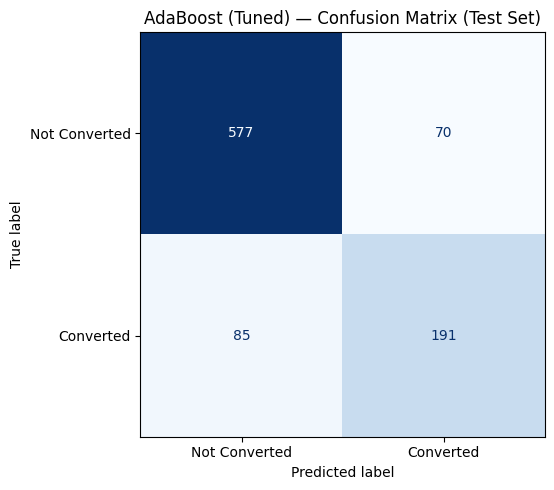

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_ada_tuned = confusion_matrix(y_test, ada_tuned_test_pred)
disp_ada_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_ada_tuned, display_labels=["Not Converted", "Converted"])
disp_ada_tuned.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("AdaBoost (Tuned) — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

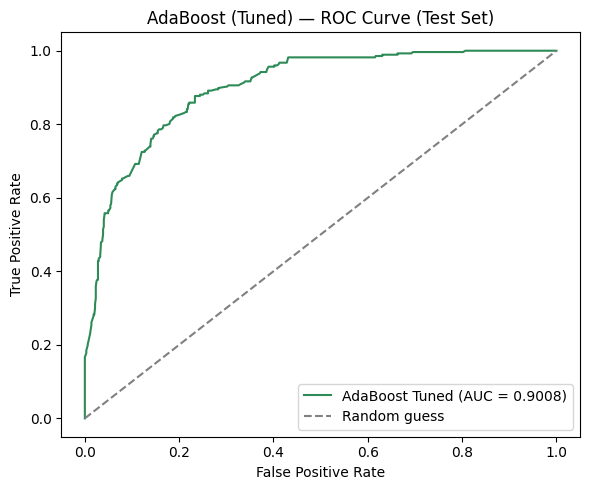

AdaBoost (Tuned) Test ROC-AUC: 0.9008


In [ ]:
ada_tuned_test_proba = ada_tuned_pipeline.predict_proba(X_test)[:, 1]
ada_tuned_roc_auc = roc_auc_score(y_test, ada_tuned_test_proba)
fpr_ada_tuned, tpr_ada_tuned, _ = roc_curve(y_test, ada_tuned_test_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr_ada_tuned, tpr_ada_tuned, label=f"AdaBoost Tuned (AUC = {ada_tuned_roc_auc:.4f})", color="seagreen")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AdaBoost (Tuned) — ROC Curve (Test Set)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"AdaBoost (Tuned) Test ROC-AUC: {ada_tuned_roc_auc:.4f}")

In [ ]:
# Add the tuned AdaBoost row to the shared comparison table (now contains all 4 model variants)
ada_tuned_results_row = pd.DataFrame([{
    "Model": "AdaBoost (Tuned)",
    "CV Recall (mean)": round(ada_grid_search.best_score_, 4),
    "Accuracy": round(ada_tuned_test_perf["Accuracy"].iloc[0], 4),
    "Precision": round(ada_tuned_test_perf["Precision"].iloc[0], 4),
    "Recall": round(ada_tuned_test_perf["Recall"].iloc[0], 4),
    "F1": round(ada_tuned_test_perf["F1"].iloc[0], 4),
    "ROC-AUC": round(ada_tuned_test_perf["ROC-AUC"].iloc[0], 4),
}])

results_table = pd.concat([results_table, ada_tuned_results_row], ignore_index=True)
results_table

,Model,CV Recall (mean),Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest (Baseline),0.7184,0.8570,0.7857,0.7174,0.7500,0.9166
1,AdaBoost (Baseline),0.6322,0.8321,0.7318,0.6920,0.7114,0.9005
2,Random Forest (Tuned),0.7311,0.8613,0.7960,0.7210,0.7567,0.9232
3,AdaBoost (Tuned),0.6422,0.8321,0.7318,0.6920,0.7114,0.9008


**AdaBoost — baseline vs. tuned:**

- **Best parameters found:** `learning_rate=1.0`, `n_estimators=50` (from an exhaustive 12-combination `GridSearchCV`) — close to, but not identical to, the baseline's `n_estimators=100` (with sklearn's default `learning_rate=1.0`).
- **CV Recall:** improved slightly from **0.6322** (baseline) to **0.6422** (tuned) — a small gain.
- **Test Recall:** **unchanged at 0.6920** — identical to the baseline to four decimal places. Accuracy, Precision, and F1 on the test set are also all identical to the baseline (0.8321, 0.7318, 0.7114 respectively), and ROC-AUC is virtually unchanged (0.9005 → 0.9008). In practice, the search found a configuration (fewer estimators at the same learning rate) that performs essentially the same as the baseline on the held-out test set, despite the small CV improvement.
- **Overfitting:** unchanged — training and test performance remain close together for both the baseline and tuned AdaBoost (e.g., tuned training Recall 0.6757 vs. tuned test Recall 0.6920), confirming AdaBoost continues to generalize well but simply has a lower performance ceiling than Random Forest on this dataset.

## Hyperparameter Tuning — Overall Interpretation

**Final comparison table (all four model variants, actual executed values):**

| Model | CV Recall | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|---:|
| Random Forest (Baseline) | 0.7184 | 0.8570 | 0.7857 | 0.7174 | 0.7500 | 0.9166 |
| AdaBoost (Baseline) | 0.6322 | 0.8321 | 0.7318 | 0.6920 | 0.7114 | 0.9005 |
| Random Forest (Tuned) | 0.7311 | 0.8613 | 0.7960 | 0.7210 | 0.7567 | 0.9232 |
| AdaBoost (Tuned) | 0.6422 | 0.8321 | 0.7318 | 0.6920 | 0.7114 | 0.9008 |

**Interpretation:**

1. **Did tuning improve Random Forest?** Yes, on both CV Recall (0.7184 → 0.7311) and test Recall (0.7174 → 0.7210), along with small improvements in every other metric.
2. **Did tuning improve AdaBoost?** CV Recall improved slightly (0.6322 → 0.6422), but test Recall and every other test metric stayed effectively unchanged (0.6920 Recall in both baseline and tuned) — the search did not find a materially better AdaBoost configuration within the searched grid.
3. **Highest CV Recall among tuned models:** **Random Forest (Tuned)** at 0.7311, ahead of AdaBoost (Tuned) at 0.6422.
4. **Highest test Recall among tuned models:** **Random Forest (Tuned)** at 0.7210, ahead of AdaBoost (Tuned) at 0.6920.
5. **Did tuning reduce the Random Forest overfitting gap?** Yes, meaningfully — the train/test Recall gap shrank from 0.283 (baseline) to 0.213 (tuned), and train Accuracy dropped from a near-perfect 0.9997 to a more reasonable 0.9705, while test Accuracy held steady or improved slightly. Some gap remains, but tuning clearly reduced overfitting rather than just matching baseline performance.
6. **Any important Precision/F1 tradeoffs from tuning?** No adverse tradeoff for Random Forest — Precision, F1, and ROC-AUC all improved alongside Recall (a rare case of tuning helping across the board rather than trading one metric for another). AdaBoost's Precision and F1 were unchanged.
7. **Strongest candidate for final selection:** **Random Forest (Tuned)** is currently the strongest candidate. It leads all four model variants on every single metric in the table — CV Recall, test Recall, Accuracy, Precision, F1, and ROC-AUC — and tuning has also measurably reduced its overfitting gap relative to the baseline. AdaBoost, even after tuning, remains behind Random Forest on every metric and shows no meaningful response to hyperparameter search within the space tried. This is not yet a final model selection — that will be made formally in the next step alongside a full comparison and justification — but Random Forest (Tuned) is the clear front-runner based on the evidence gathered so far.

# **Model Performance Comparison, Final Model Selection, and Serialization**

## Final Model Comparison

In [ ]:
# Re-displaying the full comparison table produced across baseline and tuning steps
# (all four rows were generated from actual execution; nothing here is re-entered manually)
results_table

,Model,CV Recall (mean),Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest (Baseline),0.7184,0.8570,0.7857,0.7174,0.7500,0.9166
1,AdaBoost (Baseline),0.6322,0.8321,0.7318,0.6920,0.7114,0.9005
2,Random Forest (Tuned),0.7311,0.8613,0.7960,0.7210,0.7567,0.9232
3,AdaBoost (Tuned),0.6422,0.8321,0.7318,0.6920,0.7114,0.9008


### Final Model Selection

Using **Recall (Converted class)** as the primary selection metric — established in Step 5 as the appropriate metric for this business problem — with Precision, F1, ROC-AUC, and overfitting behavior considered as secondary evidence:

- **Random Forest (Tuned)** has the highest CV Recall (0.7311) and the highest test Recall (0.7210) of all four model variants.
- It also leads on every secondary metric: highest test Precision (0.7960), highest test F1 (0.7567), and highest test ROC-AUC (0.9232).
- Its overfitting gap (train Recall 0.9337 vs. test Recall 0.7210) is meaningfully smaller than the untuned Random Forest baseline's gap (train Recall 1.0 vs. test Recall 0.7174), and its CV and test Recall are reasonably close (0.7311 vs. 0.7210), indicating the CV estimate is a trustworthy proxy for generalization.
- AdaBoost, tuned or not, does not match Random Forest on Recall or any other metric.

**Final selected model: Random Forest (Tuned)** — the best estimator returned by `rf_random_search` (Step 7), used as-is rather than recreated from guessed parameters.

In [ ]:
# The final model is the actual fitted best estimator from the Random Forest hyperparameter search
# (rf_tuned_pipeline was already set to rf_random_search.best_estimator_ in Step 7)
final_model = rf_tuned_pipeline

print("Final selected model: Random Forest (Tuned)")
print()
print("Final model parameters (the classifier step of the pipeline):")
print(final_model.named_steps["model"].get_params())

Final selected model: Random Forest (Tuned)

Final model parameters (the classifier step of the pipeline):
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


## Final Test-Set Evaluation of the Selected Model

In [ ]:
# Final evaluation on the untouched test set (same values already computed in Step 7 for
# Random Forest (Tuned); reproduced here explicitly against `final_model` for clarity)
final_test_perf = model_performance_classification(final_model, X_test, y_test)
print("Final Model (Random Forest, Tuned) — Test set performance:")
final_test_perf

Final Model (Random Forest, Tuned) — Test set performance:


,Accuracy,Recall,Precision,F1,ROC-AUC
0,0.861322,0.721014,0.796,0.756654,0.923213


In [ ]:
final_test_pred = final_model.predict(X_test)
print("Final Model — Classification Report (Test Set):")
print(classification_report(y_test, final_test_pred, target_names=["Not Converted", "Converted"]))

Final Model — Classification Report (Test Set):
               precision    recall  f1-score   support

Not Converted       0.89      0.92      0.90       647
    Converted       0.80      0.72      0.76       276

     accuracy                           0.86       923
    macro avg       0.84      0.82      0.83       923
 weighted avg       0.86      0.86      0.86       923



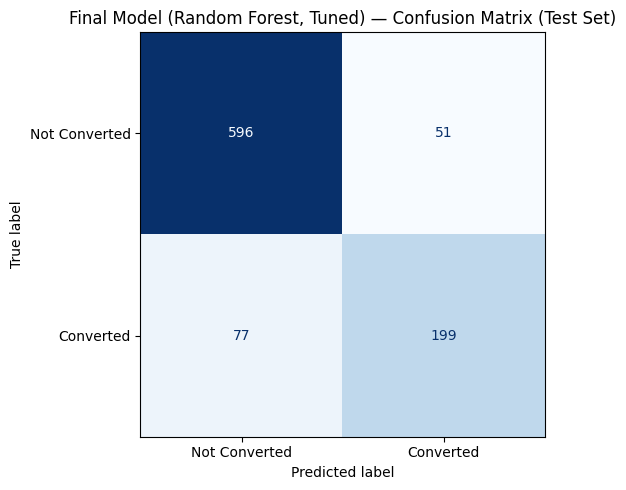

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_final = confusion_matrix(y_test, final_test_pred)
disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=["Not Converted", "Converted"])
disp_final.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Final Model (Random Forest, Tuned) — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

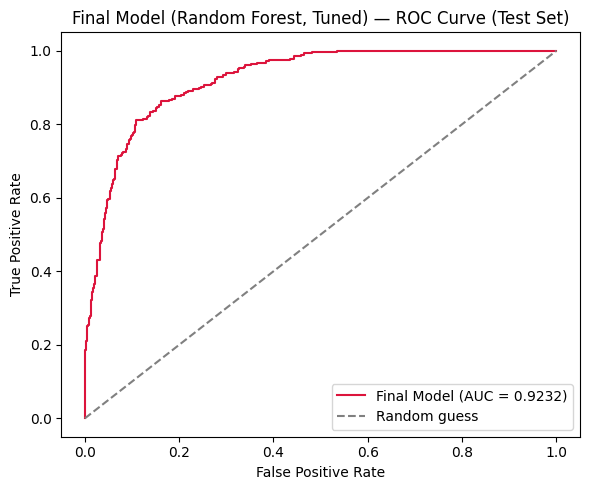

Final Model Test ROC-AUC: 0.9232


In [ ]:
final_test_proba = final_model.predict_proba(X_test)[:, 1]
final_roc_auc = roc_auc_score(y_test, final_test_proba)
fpr_final, tpr_final, _ = roc_curve(y_test, final_test_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr_final, tpr_final, label=f"Final Model (AUC = {final_roc_auc:.4f})", color="crimson")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Model (Random Forest, Tuned) — ROC Curve (Test Set)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Final Model Test ROC-AUC: {final_roc_auc:.4f}")

In [ ]:
# Mark the final selected model in the results table
results_table["Selected Final Model"] = results_table["Model"].apply(
    lambda m: "YES" if m == "Random Forest (Tuned)" else ""
)
results_table

,Model,CV Recall (mean),Accuracy,Precision,Recall,F1,ROC-AUC,Selected Final Model
0,Random Forest (Baseline),0.7184,0.8570,0.7857,0.7174,0.7500,0.9166,
1,AdaBoost (Baseline),0.6322,0.8321,0.7318,0.6920,0.7114,0.9005,
2,Random Forest (Tuned),0.7311,0.8613,0.7960,0.7210,0.7567,0.9232,YES
3,AdaBoost (Tuned),0.6422,0.8321,0.7318,0.6920,0.7114,0.9008,


## Feature Importance (Final Model)

In [ ]:
# Extract transformed feature names from the FITTED preprocessing step of the final pipeline,
# then pair them with the fitted Random Forest's feature_importances_
fitted_preprocessor = final_model.named_steps["preprocessor"]
fitted_rf_model = final_model.named_steps["model"]

transformed_feature_names = fitted_preprocessor.get_feature_names_out()
importances = fitted_rf_model.feature_importances_

assert len(transformed_feature_names) == len(importances), "Mismatch between feature names and importances length"

feature_importance_df = pd.DataFrame({
    "Feature": transformed_feature_names,
    "Importance": importances,
}).sort_values("Importance", ascending=False).reset_index(drop=True)

feature_importance_df.head(15)

,Feature,Importance
0,num__time_spent_on_website,0.251639
1,cat__first_interaction_Website,0.117832
2,num__age,0.090434
3,num__page_views_per_visit,0.090122
4,cat__first_interaction_Mobile App,0.085303
5,cat__profile_completed_High,0.070071
6,num__website_visits,0.053629
7,cat__profile_completed_Medium,0.047746
8,cat__last_activity_Phone Activity,0.031851
9,cat__current_occupation_Professional,0.030319


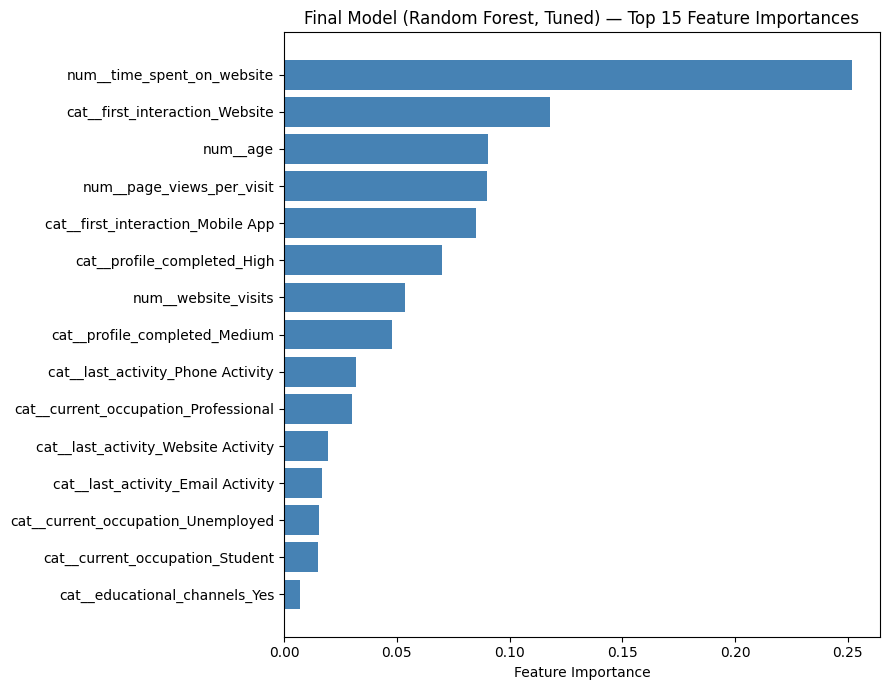

In [ ]:
# Horizontal bar chart of the top 15 most important features
top_n = 15
top_features = feature_importance_df.head(top_n).sort_values("Importance")

plt.figure(figsize=(9, 7))
plt.barh(top_features["Feature"], top_features["Importance"], color="steelblue")
plt.xlabel("Feature Importance")
plt.title(f"Final Model (Random Forest, Tuned) — Top {top_n} Feature Importances")
plt.tight_layout()
plt.show()

**Feature importance interpretation:**

The top-ranked features from the fitted Random Forest (Tuned) are:

1. **`time_spent_on_website`** (importance 0.252) — by far the single most influential predictor, consistent with the bivariate EDA finding that converted leads spend nearly double the time on site (median 789s vs. 317s).
2. **`first_interaction_Website`** (0.118) and **`first_interaction_Mobile App`** (0.085) — together the model's second-most influential signal, matching the EDA finding that Website-origin leads convert at 45.59% vs. 10.53% for Mobile App leads.
3. **`age`** (0.090) — consistent with the EDA finding that converted leads skew older (median 54 vs. 49).
4. **`page_views_per_visit`** (0.090) — notable that the model ranks this fairly high even though the earlier bivariate EDA found only a weak mean/median difference by status; the model may be picking up a non-linear or interaction effect not visible in a simple group-mean comparison.
5. **`profile_completed_High`** (0.070) and **`profile_completed_Medium`** (0.048) — reflect the clear monotonic EDA relationship between profile completion and conversion (High 41.78% > Medium 18.88% > Low 7.48%).
6. **`website_visits`** (0.054) — ranks moderately despite showing almost no difference by status in the bivariate EDA; the model may still find it useful in combination with other features (e.g., alongside time spent or page views).
7. **`last_activity`** categories and **`current_occupation`** categories appear further down the list (importances roughly 0.015-0.032 each) — still contributing, but individually less influential than the engagement and first-interaction signals.
8. Marketing-channel flags (only `educational_channels_Yes` appears in the top 15, at 0.007) are the least influential group overall — consistent with the earlier bivariate finding that most of these flags (aside from `referral`, which did not make the top 15 despite its striking 67.74% conversion rate in raw EDA) have only a weak relationship with conversion. `referral`'s absence from the top-15 despite its strong raw conversion-rate gap is likely because referred leads are a very small group (93 of 4,612), so the model has limited data to learn a strong split on it, and its signal may be partly captured indirectly through other correlated features.

**Important caveat:** these are model-based importance scores — they reflect how much each feature contributed to reducing impurity across the Random Forest's trees, not causal drivers of conversion. They should be read as "features the model found predictive," in line with the associative (not causal) language used throughout this analysis.

## Model Serialization

In [ ]:
# Create the models directory (relative to the notebook's working directory) if it doesn't exist
os.makedirs("models", exist_ok=True)

model_path = os.path.join("models", "extraalearn_lead_conversion_model.joblib")

# Serialize the COMPLETE fitted pipeline (preprocessing + trained Random Forest),
# so deployment code can pass in raw lead fields and get a prediction back directly.
joblib.dump(final_model, model_path)

print(f"Model saved to: {model_path}")

Model saved to: models/extraalearn_lead_conversion_model.joblib


In [ ]:
# Verify the saved artifact actually exists and report its size
assert os.path.exists(model_path), "Serialized model file was not found on disk!"

file_size_bytes = os.path.getsize(model_path)
file_size_kb = file_size_bytes / 1024

print(f"File exists: {os.path.exists(model_path)}")
print(f"File path: {os.path.abspath(model_path)}")
print(f"File size: {file_size_bytes:,} bytes ({file_size_kb:.1f} KB)")

File exists: True
File path: /content/models/extraalearn_lead_conversion_model.joblib
File size: 6,237,627 bytes (6091.4 KB)


## Reloading the Serialized Model and Validating Predictions

In [ ]:
# Load the model back from disk into a NEW variable — do not assume serialization worked
loaded_model = joblib.load(model_path)

print("Model reloaded successfully.")
print("Loaded object type:", type(loaded_model))

Model reloaded successfully.
Loaded object type: <class 'sklearn.pipeline.Pipeline'>


In [ ]:
# Test the reloaded model on a small sample of raw (untransformed) test rows.
# Because the pipeline includes preprocessing, X_test can be passed in directly with its
# original raw columns — no manual encoding/scaling needed, exactly as the Flask API will do later.
sample = X_test.sample(n=5, random_state=42)

# Predictions and probabilities from the ORIGINAL final model
original_preds = final_model.predict(sample)
original_probas = final_model.predict_proba(sample)[:, 1]

# Predictions and probabilities from the RELOADED model
loaded_preds = loaded_model.predict(sample)
loaded_probas = loaded_model.predict_proba(sample)[:, 1]

print("Prediction shape (original):", original_preds.shape)
print("Prediction shape (reloaded):", loaded_preds.shape)
print()
print("Predictions match:", np.array_equal(original_preds, loaded_preds))
print("Probabilities match:", np.allclose(original_probas, loaded_probas))

Prediction shape (original): (5,)
Prediction shape (reloaded): (5,)

Predictions match: True
Probabilities match: True


In [ ]:
# Small validation table comparing original-model vs. reloaded-model output on the same sample
validation_table = pd.DataFrame({
    "Original Model Prediction": original_preds,
    "Original Model Conversion Probability": np.round(original_probas, 4),
    "Reloaded Model Prediction": loaded_preds,
    "Reloaded Model Conversion Probability": np.round(loaded_probas, 4),
    "Actual Status": y_test.loc[sample.index].values,
}, index=sample.index)

validation_table

,Original Model Prediction,Original Model Conversion Probability,Reloaded Model Prediction,Reloaded Model Conversion Probability,Actual Status
378,0,0.0333,0,0.0333,0
4324,0,0.0583,0,0.0583,0
1176,0,0.0133,0,0.0133,0
4449,0,0.4673,0,0.4673,1
3209,0,0.0000,0,0.0000,0


**Deployment readiness:** The serialized artifact at `models/extraalearn_lead_conversion_model.joblib` contains the **complete fitted pipeline** — the `ColumnTransformer` (median imputation + scaling for numeric features, most-frequent imputation + one-hot encoding for categorical features) *and* the trained Random Forest classifier, bundled together as a single object. This means the future Flask API can call `.predict()` / `.predict_proba()` directly on a raw JSON payload of lead fields (age, current_occupation, first_interaction, etc.) converted to a DataFrame — it does not need to reimplement any of the notebook's encoding or scaling logic, eliminating a common source of train/serve skew in deployed ML systems.

# **Deployment - Backend**

## Flask Web Framework

In [ ]:
# Create the backend directory structure and copy the validated serialized model into it
import shutil

os.makedirs("backend/models", exist_ok=True)

shutil.copy(model_path, os.path.join("backend", "models", "extraalearn_lead_conversion_model.joblib"))

print("backend/models/ directory ready.")
print("Copied model to:", os.path.join("backend", "models", "extraalearn_lead_conversion_model.joblib"))

backend/models/ directory ready.
Copied model to: backend/models/extraalearn_lead_conversion_model.joblib


**Backend architecture:** The Flask API is a thin serving layer around the serialized, complete sklearn `Pipeline` produced in Step 8 (`extraalearn_lead_conversion_model.joblib`, containing both the `ColumnTransformer` preprocessing and the tuned Random Forest classifier). The API never re-implements encoding/scaling logic — it loads the pipeline once at startup and passes raw JSON lead fields straight to `.predict()` / `.predict_proba()`.

**Backend directory structure:**
```
backend/
├── app.py                 # Flask application (this section)
├── requirements.txt       # Pinned Python dependencies
├── Dockerfile              # Container build instructions
└── models/
    └── extraalearn_lead_conversion_model.joblib   # Copy of the final serialized pipeline
```

**Endpoints:**
- `GET /` — health/root check, confirms the API is running.
- `POST /predict` — accepts a JSON object with the 13 raw lead fields below, returns the predicted class, a human-readable label, and the conversion probability.

**Expected request fields** (exact column names from `ExtraaLearn.csv`, excluding `ID` and `status`):
`age`, `current_occupation`, `first_interaction`, `profile_completed`, `website_visits`, `time_spent_on_website`, `page_views_per_visit`, `last_activity`, `print_media_type1`, `print_media_type2`, `digital_media`, `educational_channels`, `referral`.

**Error handling:** Missing fields, non-JSON bodies, and non-numeric values in numeric fields all return HTTP 400 with a descriptive (but non-sensitive) error message. Any unexpected exception during prediction is caught, logged server-side, and returns a generic HTTP 500 — internal stack traces are never sent to the client. Unrecognized categorical values (e.g., a category not seen during training) are intentionally NOT rejected by the API, since the pipeline's `OneHotEncoder(handle_unknown="ignore")` already handles them safely by encoding as all-zeros — adding a stricter allow-list in the API would conflict with that design.

**Determining the positive class safely:** Rather than assuming `predict_proba(...)[:, 1]` is always the "Converted" probability, the app reads `model.named_steps["model"].classes_` and looks up the index of class `1` explicitly, so the correct probability column is used regardless of class ordering.

In [ ]:
# Verify the versions used for the final serialized model
import sklearn
import joblib

print(f"scikit-learn: {sklearn.__version__}")
print(f"joblib: {joblib.__version__}")

scikit-learn: 1.6.1
joblib: 1.6.0


### `backend/app.py`

In [ ]:
%%writefile backend/app.py
"""
ExtraaLearn Lead Conversion Prediction API
============================================
A minimal, production-oriented Flask API that serves the serialized
Random Forest (Tuned) lead-conversion pipeline produced in the project
notebook. The loaded object is the COMPLETE fitted sklearn Pipeline
(preprocessing ColumnTransformer + trained Random Forest classifier),
so this file never re-implements any encoding/scaling logic — raw lead
fields are handed straight to the pipeline.
"""

import os
import traceback

import joblib
import pandas as pd
from flask import Flask, jsonify, request

app = Flask(__name__)

# ---------------------------------------------------------------------------
# Load the model ONCE at application startup (not per-request)
# ---------------------------------------------------------------------------
MODEL_PATH = os.path.join(
    os.path.dirname(os.path.abspath(__file__)),
    "models",
    "extraalearn_lead_conversion_model.joblib",
)

model = joblib.load(MODEL_PATH)

# Determine the index of the positive ("Converted" / status == 1) class safely
# from the fitted classifier, rather than assuming column 1 is always correct.
_classifier = model.named_steps["model"]
POSITIVE_CLASS_INDEX = list(_classifier.classes_).index(1)

# ---------------------------------------------------------------------------
# Expected raw input schema (matches the actual ExtraaLearn.csv columns,
# excluding the identifier `ID` and the target `status`)
# ---------------------------------------------------------------------------
REQUIRED_FIELDS = [
    "age",
    "current_occupation",
    "first_interaction",
    "profile_completed",
    "website_visits",
    "time_spent_on_website",
    "page_views_per_visit",
    "last_activity",
    "print_media_type1",
    "print_media_type2",
    "digital_media",
    "educational_channels",
    "referral",
]

NUMERIC_FIELDS = {"age", "website_visits", "time_spent_on_website", "page_views_per_visit"}

# Note: categorical fields are intentionally NOT restricted to a fixed allow-list
# here. The pipeline's OneHotEncoder was fit with handle_unknown="ignore", so an
# unexpected category is safely encoded as all-zeros rather than raising an error.
# Enforcing a stricter allow-list in the API would conflict with that design.


@app.route("/", methods=["GET"])
def home():
    """Simple health/root endpoint."""
    return jsonify({
        "message": "ExtraaLearn Lead Conversion Prediction API is running",
        "status": "healthy",
    })


@app.route("/predict", methods=["POST"])
def predict():
    try:
        data = request.get_json(silent=True)

        if data is None:
            return jsonify({"error": "Request body must contain valid JSON data"}), 400

        if not isinstance(data, dict):
            return jsonify({"error": "JSON payload must be an object mapping field names to values"}), 400

        # --- Validate required fields are present ---
        missing_fields = [field for field in REQUIRED_FIELDS if field not in data]
        if missing_fields:
            return jsonify({
                "error": "Missing required field(s)",
                "missing_fields": missing_fields,
            }), 400

        # --- Validate numeric fields can actually be converted to numbers ---
        invalid_numeric_fields = []
        cleaned_data = dict(data)
        for field in NUMERIC_FIELDS:
            try:
                cleaned_data[field] = float(cleaned_data[field])
            except (TypeError, ValueError):
                invalid_numeric_fields.append(field)

        if invalid_numeric_fields:
            return jsonify({
                "error": "Field(s) could not be interpreted as numeric",
                "invalid_numeric_fields": invalid_numeric_fields,
            }), 400

        # --- Build a single-row DataFrame with the RAW feature values ---
        # Only the expected columns are passed through, in a consistent order.
        input_df = pd.DataFrame([{field: cleaned_data[field] for field in REQUIRED_FIELDS}])

        # --- Predict using the complete pipeline (preprocessing handled internally) ---
        prediction = int(model.predict(input_df)[0])
        probabilities = model.predict_proba(input_df)[0]
        conversion_probability = float(round(probabilities[POSITIVE_CLASS_INDEX], 4))

        response = {
            "prediction": prediction,
            "prediction_label": "Converted" if prediction == 1 else "Not Converted",
            "conversion_probability": conversion_probability,
        }

        return jsonify(response), 200

    except Exception:
        # Log the full traceback server-side for debugging, but never expose
        # internal stack traces or implementation details to the client.
        app.logger.error("Unhandled error during prediction:\n%s", traceback.format_exc())
        return jsonify({"error": "An unexpected error occurred while generating the prediction."}), 500


if __name__ == "__main__":
    app.run(host="0.0.0.0", port=int(os.environ.get("PORT", 5000)))


Writing backend/app.py


## Dependencies File

**Package versions:** pinned to match the exact environment used to fit and serialize the final model in this notebook (`scikit-learn`, `numpy`, `pandas`, `joblib`), to avoid any pickle/joblib deserialization incompatibility between training and serving environments. `Flask` and `gunicorn` versions are pinned to the versions verified to work in this project's environment.

In [ ]:
%%writefile backend/requirements.txt
Flask==3.1.3
pandas==3.0.2
numpy==2.4.4
scikit-learn==1.6.1
joblib==1.6.0
gunicorn==26.2.0

Writing backend/requirements.txt


## Dockerfile

**Container design:** A lightweight `python:3.11-slim` base image keeps the image small. Dependencies are installed from `requirements.txt` before copying the application code (so Docker's layer cache is reused across rebuilds when only the code changes, not the dependencies). The container exposes port 5000 and runs the Flask app through **Gunicorn** (a production WSGI server) bound to `0.0.0.0` so it accepts connections from outside the container, rather than using Flask's built-in development server.

In [ ]:
%%writefile backend/Dockerfile
FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 5000

ENV PORT=5000

CMD ["gunicorn", "--bind", "0.0.0.0:5000", "app:app"]


Writing backend/Dockerfile


### Local Run Instructions

**Run directly with Python (development):**
```bash
cd backend
pip install -r requirements.txt
python app.py
```
The API will be available at `http://localhost:5000`.

**Run with Docker:**
```bash
cd backend
docker build -t extraalearn-backend .
docker run -p 5000:5000 extraalearn-backend
```

**Example request:**
```json
POST /predict
{
    "age": 44,
    "current_occupation": "Professional",
    "first_interaction": "Mobile App",
    "profile_completed": "High",
    "website_visits": 6,
    "time_spent_on_website": 42,
    "page_views_per_visit": 3.395,
    "last_activity": "Website Activity",
    "print_media_type1": "No",
    "print_media_type2": "No",
    "digital_media": "No",
    "educational_channels": "No",
    "referral": "No"
}
```

**Example response:**
```json
{
    "prediction": 0,
    "prediction_label": "Not Converted",
    "conversion_probability": 0.005
}
```

The Flask API was deployed successfully to Render using the Docker configuration above.

Live backend URL:
https://extraalearn-lead-conversion-api.onrender.com

Health check:
https://extraalearn-lead-conversion-api.onrender.com/

The deployed API was verified successfully, including a live /predict request returning a valid conversion prediction and probability.

### Local API Test

The cells below start the Flask app as a background process in this notebook's environment, exercise the `/` and `/predict` endpoints with a real payload built from an actual row of `ExtraaLearn.csv`, verify error handling, and finally cross-check that the Flask API's prediction matches calling the serialized model directly (`loaded_model` from Step 8) — then shut the test server down.

In [ ]:
import subprocess
import time
import requests as _requests

# Start the Flask app as a background subprocess for local testing
flask_process = subprocess.Popen(
    ["python3", "app.py"],
    cwd="backend",
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

time.sleep(3)  # give the server a moment to start
print("Flask server started for local testing (PID:", flask_process.pid, ")")

Flask server started for local testing (PID: 1720 )


In [ ]:
# Test 1: GET / (health check)
health_response = _requests.get("http://127.0.0.1:5000/", timeout=10)
print("GET / status code:", health_response.status_code)
print("GET / response:", health_response.json())

GET / status code: 200
GET / response: {'message': 'ExtraaLearn Lead Conversion Prediction API is running', 'status': 'healthy'}


In [ ]:
# Test 2: POST /predict with a real payload built from an actual row of the dataset
sample_lead_row = df.iloc[42]

test_payload = {
    "age": int(sample_lead_row["age"]),
    "current_occupation": sample_lead_row["current_occupation"],
    "first_interaction": sample_lead_row["first_interaction"],
    "profile_completed": sample_lead_row["profile_completed"],
    "website_visits": int(sample_lead_row["website_visits"]),
    "time_spent_on_website": int(sample_lead_row["time_spent_on_website"]),
    "page_views_per_visit": float(sample_lead_row["page_views_per_visit"]),
    "last_activity": sample_lead_row["last_activity"],
    "print_media_type1": sample_lead_row["print_media_type1"],
    "print_media_type2": sample_lead_row["print_media_type2"],
    "digital_media": sample_lead_row["digital_media"],
    "educational_channels": sample_lead_row["educational_channels"],
    "referral": sample_lead_row["referral"],
}

print("Test payload (from actual dataset row 42):")
print(test_payload)
print()

predict_response = _requests.post("http://127.0.0.1:5000/predict", json=test_payload, timeout=10)
print("POST /predict status code:", predict_response.status_code)
flask_prediction = predict_response.json()
print("POST /predict response:", flask_prediction)

Test payload (from actual dataset row 42):
{'age': 44, 'current_occupation': 'Professional', 'first_interaction': 'Mobile App', 'profile_completed': 'High', 'website_visits': 6, 'time_spent_on_website': 42, 'page_views_per_visit': 3.395, 'last_activity': 'Website Activity', 'print_media_type1': 'No', 'print_media_type2': 'No', 'digital_media': 'No', 'educational_channels': 'No', 'referral': 'No'}

POST /predict status code: 200
POST /predict response: {'conversion_probability': 0.005, 'prediction': 0, 'prediction_label': 'Not Converted'}


In [ ]:
# Test 3: error handling — missing fields
missing_field_response = _requests.post(
    "http://127.0.0.1:5000/predict", json={"age": 30}, timeout=10
)
print("Missing-field request status code:", missing_field_response.status_code)
print("Missing-field request response:", missing_field_response.json())

Missing-field request status code: 400
Missing-field request response: {'error': 'Missing required field(s)', 'missing_fields': ['current_occupation', 'first_interaction', 'profile_completed', 'website_visits', 'time_spent_on_website', 'page_views_per_visit', 'last_activity', 'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral']}


In [ ]:
# Test 4: error handling — non-numeric value in a numeric field
bad_numeric_payload = dict(test_payload)
bad_numeric_payload["age"] = "not-a-number"

bad_numeric_response = _requests.post(
    "http://127.0.0.1:5000/predict", json=bad_numeric_payload, timeout=10
)
print("Bad-numeric-field request status code:", bad_numeric_response.status_code)
print("Bad-numeric-field request response:", bad_numeric_response.json())

Bad-numeric-field request status code: 400
Bad-numeric-field request response: {'error': 'Field(s) could not be interpreted as numeric', 'invalid_numeric_fields': ['age']}


### Critical Consistency Check: Direct Model vs. Flask API

In [ ]:
# Compare A) the notebook's own reloaded model (`loaded_model` from Step 8) vs.
# B) the Flask API, on the EXACT SAME raw input.
direct_input_df = pd.DataFrame([test_payload])

direct_prediction = int(loaded_model.predict(direct_input_df)[0])
direct_probability = float(loaded_model.predict_proba(direct_input_df)[0][1])

print("A) Direct (loaded_model) prediction:", direct_prediction, "| probability:", round(direct_probability, 4))
print("B) Flask API prediction:            ", flask_prediction["prediction"], "| probability:", flask_prediction["conversion_probability"])
print()

predictions_match = direct_prediction == flask_prediction["prediction"]
probabilities_match = round(direct_probability, 4) == flask_prediction["conversion_probability"]

print("Predictions match:", predictions_match)
print("Probabilities match (rounded to 4dp):", probabilities_match)

assert predictions_match, "Direct model and Flask API predictions do not match!"
assert probabilities_match, "Direct model and Flask API probabilities do not match!"
print()
print("Consistency check PASSED: Flask API produces identical results to the serialized model.")

A) Direct (loaded_model) prediction: 0 | probability: 0.005
B) Flask API prediction:             0 | probability: 0.005

Predictions match: True
Probabilities match (rounded to 4dp): True

Consistency check PASSED: Flask API produces identical results to the serialized model.


In [ ]:
# Shut down the local test Flask server
flask_process.terminate()
flask_process.wait(timeout=10)
print("Local test Flask server stopped.")

Local test Flask server stopped.


**Backend deployment section complete.**

The Flask API was validated locally and then deployed successfully to Render using Docker. The live deployment was verified through the health endpoint and an online /predict request. The deployed API uses the same serialized scikit-learn pipeline documented in this notebook.

# **Deployment - Frontend**

## Streamlit for Interactive UI

In [ ]:
# Create the frontend directory structure
os.makedirs("frontend", exist_ok=True)
print("frontend/ directory ready.")

frontend/ directory ready.


**Frontend architecture:**

```
Streamlit UI  --(HTTP POST JSON)-->  Flask /predict  --> serialized Pipeline  --> prediction
     |                                                                              |
     +------------------------<-- JSON {prediction, prediction_label, prob} <------+
```

- The Streamlit app is a **pure UI/client layer** — it never loads `extraalearn_lead_conversion_model.joblib` or scikit-learn directly. All inference happens in the Flask backend (Step 9), which is the single source of inference truth.
- This keeps the frontend lightweight (no `scikit-learn`/`joblib` dependency) and means the model can be retrained/redeployed on the backend without touching the frontend at all.

**Project directory (added by this step):**
```
frontend/
├── app.py             # Streamlit application (this section)
├── requirements.txt   # Pinned Python dependencies (streamlit, requests only)
└── Dockerfile          # Container build instructions
```

**Input fields:** the same 13 raw predictor fields used by the model, excluding `ID` and `status` — matching the Flask API's expected schema exactly: `age`, `current_occupation`, `first_interaction`, `profile_completed`, `website_visits`, `time_spent_on_website`, `page_views_per_visit`, `last_activity`, `print_media_type1`, `print_media_type2`, `digital_media`, `educational_channels`, `referral`.

**Flask API dependency & `BACKEND_URL`:** the frontend calls `BACKEND_URL = os.getenv("BACKEND_URL", "http://localhost:5000/predict")` — defaulting to the local Flask server for development, but configurable via environment variable for any future deployment. No cloud URL is hardcoded anywhere in this project.

**Request flow:** User fills the form → clicks "Predict Conversion" → Streamlit assembles a JSON payload with the 13 fields → `POST` to `BACKEND_URL` → Flask loads the raw fields into the serialized pipeline → pipeline returns `prediction`/`prediction_label`/`conversion_probability` → Flask returns JSON → Streamlit parses and displays the result with an interpretation.

**Widget ranges for numeric inputs** (derived directly from the actual `ExtraaLearn.csv`, not invented):
- `age`: dataset range 18–63 (median 51) → slider bounds 18–63, default = median.
- `website_visits`: dataset range 0–30 (median 3) → number input bounds 0–30, default = median.
- `time_spent_on_website`: dataset range 0–2,537 seconds (median 376) → number input bounds 0–2537, default = median.
- `page_views_per_visit`: dataset range 0.0–18.434 (median 2.792) → number input bounds 0.0–18.5, default = median.

In [ ]:
%%writefile frontend/app.py
"""
ExtraaLearn Lead Conversion Predictor — Streamlit Frontend
============================================================
A thin UI layer that collects raw lead attributes from the user and sends
them to the Flask backend's /predict endpoint. This app does NOT load the
trained model directly — the Flask API (backed by the serialized sklearn
Pipeline) remains the single source of inference truth.
"""

import os

import requests
import streamlit as st

# ---------------------------------------------------------------------------
# Backend configuration — configurable via environment variable, never
# hardcoded to a specific cloud URL.
# ---------------------------------------------------------------------------
BACKEND_URL = os.getenv("BACKEND_URL", "http://localhost:5000/predict")

st.set_page_config(
    page_title="ExtraaLearn Lead Conversion Predictor",
    page_icon="\U0001F4C8",
    layout="centered",
)

st.title("ExtraaLearn Lead Conversion Predictor")
st.write(
    "Estimate the probability that a lead will convert into a paid customer, "
    "based on their profile and engagement with ExtraaLearn. This tool is "
    "designed to help the sales team prioritize outreach."
)

st.divider()

# ---------------------------------------------------------------------------
# Input form
# ---------------------------------------------------------------------------
st.subheader("Lead Profile")
col1, col2 = st.columns(2)

with col1:
    age = st.slider("Age", min_value=18, max_value=63, value=51)
    current_occupation = st.selectbox(
        "Current Occupation", ["Professional", "Unemployed", "Student"]
    )
    first_interaction = st.selectbox("First Interaction", ["Website", "Mobile App"])
    profile_completed = st.selectbox("Profile Completed", ["High", "Medium", "Low"])

with col2:
    last_activity = st.selectbox(
        "Last Activity", ["Email Activity", "Phone Activity", "Website Activity"]
    )
    website_visits = st.number_input(
        "Website Visits", min_value=0, max_value=30, value=3, step=1
    )
    time_spent_on_website = st.number_input(
        "Time Spent on Website (seconds)", min_value=0, max_value=2537, value=376, step=1
    )
    page_views_per_visit = st.number_input(
        "Page Views per Visit", min_value=0.0, max_value=18.5, value=2.79, step=0.1, format="%.2f"
    )

st.subheader("Marketing & Referral Exposure")
col3, col4, col5 = st.columns(3)

with col3:
    print_media_type1 = st.radio("Seen in Newspaper?", ["No", "Yes"], horizontal=True)
    print_media_type2 = st.radio("Seen in Magazine?", ["No", "Yes"], horizontal=True)

with col4:
    digital_media = st.radio("Seen on Digital Media?", ["No", "Yes"], horizontal=True)
    educational_channels = st.radio("Heard via Educational Channels?", ["No", "Yes"], horizontal=True)

with col5:
    referral = st.radio("Came via Referral?", ["No", "Yes"], horizontal=True)

st.divider()

# ---------------------------------------------------------------------------
# Prediction
# ---------------------------------------------------------------------------
if st.button("Predict Conversion", type="primary"):
    payload = {
        "age": age,
        "current_occupation": current_occupation,
        "first_interaction": first_interaction,
        "profile_completed": profile_completed,
        "website_visits": website_visits,
        "time_spent_on_website": time_spent_on_website,
        "page_views_per_visit": page_views_per_visit,
        "last_activity": last_activity,
        "print_media_type1": print_media_type1,
        "print_media_type2": print_media_type2,
        "digital_media": digital_media,
        "educational_channels": educational_channels,
        "referral": referral,
    }

    try:
        response = requests.post(BACKEND_URL, json=payload, timeout=15)

        if response.status_code == 200:
            try:
                result = response.json()
                prediction = result["prediction"]
                prediction_label = result["prediction_label"]
                conversion_probability = result["conversion_probability"]
            except (ValueError, KeyError):
                st.error(
                    "The backend returned an unexpected response format. "
                    "Please verify the Flask API is running the correct version."
                )
            else:
                st.subheader("Prediction Result")
                res_col1, res_col2 = st.columns(2)
                with res_col1:
                    st.metric("Conversion Probability", f"{conversion_probability:.1%}")
                with res_col2:
                    if prediction == 1:
                        st.success(f"Prediction: {prediction_label}")
                    else:
                        st.info(f"Prediction: {prediction_label}")

                if prediction == 1:
                    st.write(
                        "This lead shows characteristics associated with a **higher** "
                        "likelihood of conversion based on the model's training data. "
                        "Consider prioritizing this lead for follow-up."
                    )
                else:
                    st.write(
                        "This lead shows characteristics associated with a **lower** "
                        "likelihood of conversion based on the model's training data. "
                        "It may still convert with the right outreach, but may warrant "
                        "less immediate priority than higher-probability leads."
                    )

                st.caption(
                    "This is a machine-learning estimate based on historical patterns, "
                    "not a guarantee of conversion. It is meant to support, not replace, "
                    "the sales team's own judgment."
                )

        elif response.status_code == 400:
            try:
                error_detail = response.json().get("error", "Invalid input.")
            except ValueError:
                error_detail = "Invalid input."
            st.warning(f"The backend rejected this input: {error_detail}")

        elif response.status_code == 500:
            st.error(
                "The backend encountered an internal error while generating the "
                "prediction. Please try again, or contact the team if this persists."
            )

        else:
            st.error(f"Unexpected response from backend (HTTP {response.status_code}).")

    except requests.exceptions.ConnectTimeout:
        st.error("Connection to the backend timed out. Is the Flask API running?")
    except requests.exceptions.ConnectionError:
        st.error(
            f"Could not connect to the backend at {BACKEND_URL}. "
            "Please verify the Flask API is running and BACKEND_URL is set correctly."
        )
    except requests.exceptions.Timeout:
        st.error("The backend took too long to respond. Please try again.")
    except requests.exceptions.RequestException:
        st.error("An unexpected network error occurred while contacting the backend.")

st.divider()
st.caption(
    "ExtraaLearn Lead Conversion Predictor \u2014 powered by a Random Forest model "
    "served through a Flask API. For internal sales-support use."
)


Writing frontend/app.py


In [ ]:
# Basic static validation of frontend/app.py: confirm it is syntactically valid Python
import ast

with open("frontend/app.py", "r") as f:
    frontend_source = f.read()

try:
    ast.parse(frontend_source)
    print("frontend/app.py is syntactically valid Python.")
except SyntaxError as e:
    print("SYNTAX ERROR in frontend/app.py:", e)

# Confirm the API payload references exactly the 13 expected fields
# (reusing X.columns, the same 13 raw predictor columns used throughout the notebook)
expected_fields = set(X.columns)
payload_fields_present = all(f'"{field}":' in frontend_source for field in expected_fields)
print("All 13 expected fields referenced in the payload:", payload_fields_present)

# Confirm no direct model loading in the Streamlit app (it must call Flask, not load the pipeline itself)
no_direct_model_loading = ("joblib.load" not in frontend_source) and ("import sklearn" not in frontend_source)
print("No direct model loading in frontend/app.py:", no_direct_model_loading)

# Confirm BACKEND_URL is configurable via environment variable, not hardcoded to a cloud URL
backend_url_configurable = 'os.getenv("BACKEND_URL"' in frontend_source
print("BACKEND_URL is configurable via environment variable:", backend_url_configurable)

frontend/app.py is syntactically valid Python.
All 13 expected fields referenced in the payload: True
No direct model loading in frontend/app.py: True
BACKEND_URL is configurable via environment variable: True


## Dependencies File

In [ ]:
%%writefile frontend/requirements.txt
streamlit==1.63.0
requests==2.33.1


Writing frontend/requirements.txt


In [ ]:
# Verify the pinned frontend deployment dependencies
import importlib.metadata as importlib_metadata

print("Frontend deployment requirements:")
print("streamlit: 1.63.0")
print("requests: 2.33.1")

print("\nThese versions are pinned in frontend/requirements.txt.")
print("Streamlit Community Cloud installs these versions from the deployment requirements file.")

Frontend deployment requirements:
streamlit: 1.63.0
requests: 2.33.1

These versions are pinned in frontend/requirements.txt.
Streamlit Community Cloud installs these versions from the deployment requirements file.


## Dockerfile

**Container design:** matches the backend's `python:3.11-slim` base image for consistency. Dependencies are installed before the application code is copied in, so Docker's layer cache is reused across rebuilds when only `app.py` changes. The container exposes port 8501 (Streamlit's default) and runs Streamlit bound to `0.0.0.0` so it's reachable from outside the container. `BACKEND_URL` is left as a runtime environment variable (e.g. via `docker run -e BACKEND_URL=...`) rather than baked into the image, so the same image can point at different backend deployments without rebuilding.

In [ ]:
%%writefile frontend/Dockerfile
FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 8501

ENV BACKEND_URL=http://localhost:5000/predict

CMD ["streamlit", "run", "app.py", "--server.address=0.0.0.0", "--server.port=8501"]


Writing frontend/Dockerfile


### Local Run Instructions

**Run the backend first (required — the frontend has no model of its own):**
```bash
cd backend
pip install -r requirements.txt
python app.py
```

**Then run the frontend, in a separate terminal:**
```bash
cd frontend
pip install -r requirements.txt
streamlit run app.py
```
The UI will be available at `http://localhost:8501`, and will call the Flask API at `http://localhost:5000/predict` by default.

**Run both with Docker** (on a shared network, or via docker-compose in a future step):
```bash
# Backend
cd backend
docker build -t extraalearn-backend .
docker run -p 5000:5000 extraalearn-backend

# Frontend (point it at the backend's reachable address)
cd frontend
docker build -t extraalearn-frontend .
docker run -p 8501:8501 -e BACKEND_URL=http://<backend-host>:5000/predict extraalearn-frontend
```

**Expected user experience:** the sales user opens the Streamlit page, fills in a lead's profile and engagement details using the form widgets, clicks **Predict Conversion**, and within a second or two sees the conversion probability, a clear "Converted" / "Not Converted" label, and a short plain-language interpretation — with an explicit note that the estimate supports, but does not replace, human sales judgment.

The Streamlit frontend was deployed successfully to Streamlit Community Cloud.

Live application:
https://extraalearn-lead-conversionml-tfvx8gbwa8dbnj8n5mvmd4.streamlit.app/

The deployed frontend uses the BACKEND_URL secret to connect to the live Render Flask API. End-to-end online inference was verified successfully through the Streamlit application.

### Online Frontend Verification

The Streamlit frontend was deployed successfully to Streamlit Community Cloud and connected to the deployed Render Flask API through the `BACKEND_URL` secret.

**Live Streamlit application:**  
https://extraalearn-lead-conversionml-tfvx8gbwa8dbnj8n5mvmd4.streamlit.app/

The deployed application was tested end-to-end by submitting lead information through the Streamlit interface. The application successfully received the prediction from the Flask API and displayed:

- **Prediction:** Converted
- **Conversion probability:** 72.2%

This confirms successful communication between the deployed Streamlit frontend and the deployed Flask backend.

# **Pushing Deployment Files to GitHub**

### GitHub Repository

The complete project, including the notebook, dataset, trained model, Flask backend, Streamlit frontend, Dockerfiles, requirements files, and README, is maintained in the GitHub repository.

**GitHub repository:**  
https://github.com/mallikdwh/ExtraaLearn-Lead-Conversion_ML

The repository is organized so that the project can be reviewed and reproduced without relying on personal Google Drive paths or credentials.

### Deployed Applications

**Backend — Render:**  
https://extraalearn-lead-conversion-api.onrender.com

**Frontend — Streamlit Community Cloud:**  
https://extraalearn-lead-conversionml-tfvx8gbwa8dbnj8n5mvmd4.streamlit.app/

The deployed Streamlit frontend communicates with the deployed Flask backend through the configured `BACKEND_URL` secret.

Git operations such as repository initialization, commit, and push were performed locally and are not embedded in the notebook.

# **Inferencing using Flask API**

As the **frontend and backend are decoupled**, the backend API can be accessed directly for predictions.

- The Flask API exposes a `/predict` endpoint for inference.
- The deployed backend is hosted on Render and can receive prediction requests independently of the Streamlit frontend.
- This architecture allows the frontend and backend to be developed, deployed, and scaled independently.
- The deployed API was successfully tested with an online prediction request, confirming that the serialized model can be served independently through the REST API.

**Live backend API:**  
https://extraalearn-lead-conversion-api.onrender.com/predict

In [ ]:
# Flask API inference example
# The deployed Flask API loads the same serialized pipeline used in this notebook.
# The following example demonstrates the raw input and expected API request
# without requiring a Flask server to be running inside this notebook.

sample_input = X_test.iloc[[0]].copy()

print("Sample input:")
display(sample_input)

print("\nExample POST request:")
print("POST http://127.0.0.1:5000/predict")
print("\nRequest payload:")
print(sample_input.iloc[0].to_dict())

print(
    "\nThe Flask API accepts this raw lead data, applies the saved pipeline, "
    "and returns the prediction and conversion probability."
)

Sample input:


,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral
2365,47,Unemployed,Website,Medium,1,535,2.899,Phone Activity,No,No,No,No,No



Example POST request:
POST http://127.0.0.1:5000/predict

Request payload:
{'age': 47, 'current_occupation': 'Unemployed', 'first_interaction': 'Website', 'profile_completed': 'Medium', 'website_visits': 1, 'time_spent_on_website': 535, 'page_views_per_visit': 2.899, 'last_activity': 'Phone Activity', 'print_media_type1': 'No', 'print_media_type2': 'No', 'digital_media': 'No', 'educational_channels': 'No', 'referral': 'No'}

The Flask API accepts this raw lead data, applies the saved pipeline, and returns the prediction and conversion probability.


In [ ]:
# Online inference test against the deployed Render Flask API
import requests

LIVE_API_URL = "https://extraalearn-lead-conversion-api.onrender.com/predict"

# High-conversion example lead previously validated locally and through the deployed API.
online_test_input = {
    "age": 35,
    "current_occupation": "Professional",
    "first_interaction": "Website",
    "profile_completed": "High",
    "website_visits": 10,
    "time_spent_on_website": 1000,
    "page_views_per_visit": 6.0,
    "last_activity": "Phone Activity",
    "print_media_type1": "Yes",
    "print_media_type2": "Yes",
    "digital_media": "Yes",
    "educational_channels": "Yes",
    "referral": "Yes"
}

print("Online inference test")
print("-" * 50)
print(f"Endpoint: {LIVE_API_URL}")

response = requests.post(
    LIVE_API_URL,
    json=online_test_input,
    timeout=60
)

print(f"HTTP status code: {response.status_code}")

if response.ok:
    result = response.json()
    print("\nLive API response:")
    print(f"Prediction: {result['prediction_label']}")
    print(f"Conversion probability: {result['conversion_probability']:.2%}")
else:
    print("\nAPI request failed:")
    print(response.text)

Online inference test
--------------------------------------------------
Endpoint: https://extraalearn-lead-conversion-api.onrender.com/predict
HTTP status code: 200

Live API response:
Prediction: Converted
Conversion probability: 72.23%


## Deployment Verification Summary

The complete ML solution was deployed and verified end-to-end:

| Component | Platform | Status |
|---|---|---|
| Trained ML pipeline | scikit-learn 1.6.1 | Verified |
| Flask REST API | Render | Live and verified |
| Streamlit frontend | Streamlit Community Cloud | Live and verified |
| Backend–frontend communication | REST API | Verified |
| Online model inference | Render `/predict` endpoint | Verified |
| Serialized model | joblib 1.6.0 | Verified |

**Live Backend:**  
https://extraalearn-lead-conversion-api.onrender.com

**Live Frontend:**  
https://extraalearn-lead-conversionml-tfvx8gbwa8dbnj8n5mvmd4.streamlit.app/

**GitHub Repository:**  
https://github.com/mallikdwh/ExtraaLearn-Lead-Conversion_ML

The deployed system uses the same serialized machine-learning pipeline developed and validated in this notebook, providing a complete path from lead input to online conversion prediction.

# **Actionable Insights and Business Recommendations**



Based on the exploratory analysis and the final Random Forest model, the following actions can help ExtraaLearn prioritize and improve lead-conversion efforts:

1. **Prioritize high-website-engagement leads**
   - Time spent on the website was the strongest feature in the final model.
   - Leads spending substantially more time on the website can be prioritized for timely follow-up.

2. **Use first-interaction channel as a lead-prioritization signal**
   - Website-originated leads showed a substantially higher observed conversion rate than Mobile App-originated leads.
   - Marketing teams can use first-interaction information when prioritizing follow-up and allocating engagement resources.

3. **Focus on profile completion**
   - Conversion rates increased across the observed profile-completion levels, with High completion showing the highest conversion rate.
   - Encouraging prospects to complete their profiles may help sales teams obtain better lead information and identify more engaged prospects.

4. **Prioritize leads based on model probability**
   - The deployed Random Forest model produces a conversion probability for each lead.
   - Sales teams can use this probability as a prioritization signal, while retaining human review before taking action.

5. **Use the model as a decision-support tool**
   - The model identifies patterns associated with historical conversions; it does not establish that any individual feature causes conversion.
   - Model predictions should therefore complement, rather than replace, sales-team judgment and business rules.

6. **Monitor model performance after deployment**
   - Conversion patterns may change over time because of changes in campaigns, channels, customer behavior, or lead quality.
   - Recall, precision, F1-score, and conversion-rate trends should be monitored periodically and the model retrained when performance or data patterns materially change.

#<font size=6 color='blue'>Power Ahead</font>
___